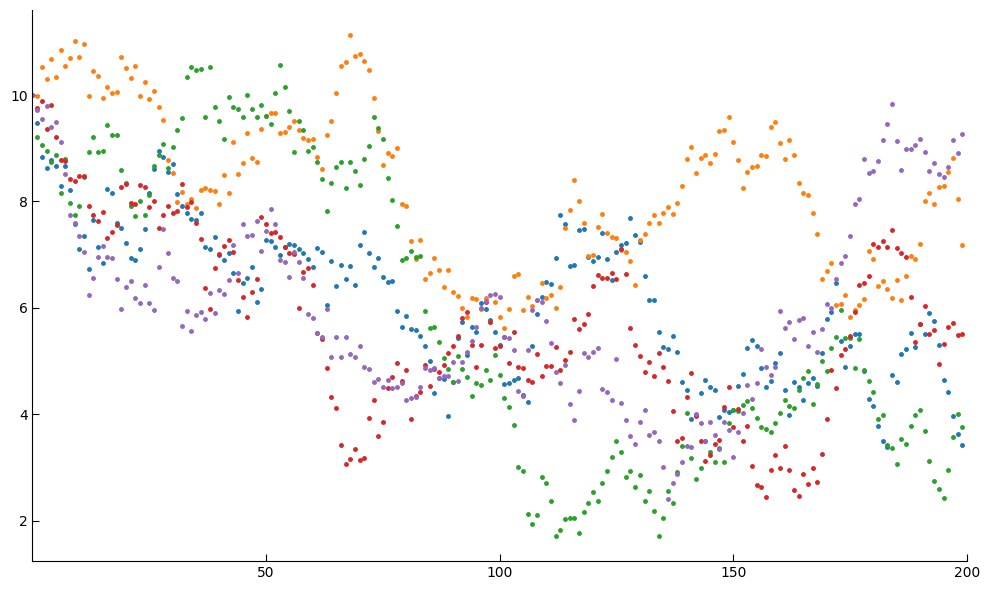

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_ou_process(theta, mu, sigma, X0, dt, N, num_paths):
    """
    Simulates multiple paths of an Ornstein-Uhlenbeck process.
    """
    # Initialize the array to store the paths
    X = np.zeros((N, num_paths))
    X[0, :] = X0
    
    # Generate random noise for all steps and paths at once
    Z = np.random.normal(0, 1, (N - 1, num_paths))
    
    # Simulate the process using the Euler-Maruyama method
    for t in range(1, N):
        X[t, :] = X[t-1, :] + theta * (mu - X[t-1, :]) * dt + sigma * np.sqrt(dt) * Z[t-1, :]
        
    return X

# --- Parameters ---
# Tuned to approximate the visual behavior in the provided image
num_paths = 5       # Number of distinct paths (lines)
N = 200             # Number of time steps (matches x-axis)
dt = 1.0            # Time step size
X0 = 10.0           # Starting value (matches y-axis origin)
theta = 0.02        # Mean reversion speed (low, so it drifts noticeably)
mu = 5.0            # Long-term mean (pulling the process downwards)
sigma = 0.4         # Volatility (size of the random jumps)

# Generate the data
paths = simulate_ou_process(theta, mu, sigma, X0, dt, N, num_paths)
time_steps = np.arange(N)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each path using discrete dots to match the image style
for i in range(num_paths):
    ax.plot(time_steps, paths[:, i], marker='.', linestyle='None', markersize=5)

# Formatting to match the provided image's clean aesthetic
ax.set_xlim(0, N)
ax.set_xticks([50, 100, 150, 200]) # Match x-axis ticks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', direction='in', length=5)

plt.tight_layout()
plt.show()

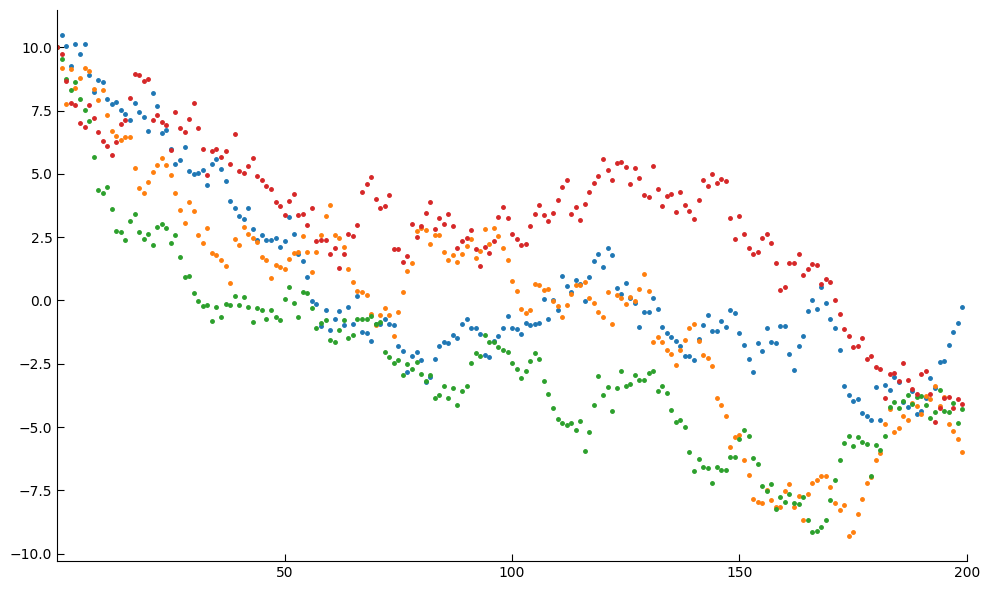

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_ou_process(theta, mu, sigma, X0, dt, N, num_paths):
    """
    Simulates multiple paths of an Ornstein-Uhlenbeck process.
    """
    X = np.zeros((N, num_paths))
    X[0, :] = X0
    
    Z = np.random.normal(0, 1, (N - 1, num_paths))
    
    for t in range(1, N):
        X[t, :] = X[t-1, :] + theta * (mu - X[t-1, :]) * dt + sigma * np.sqrt(dt) * Z[t-1, :]
        
    return X

# --- Updated Parameters ---
num_paths = 4       
N = 200             
dt = 1.0            
X0 = 10.0           

# 1. Lower 'mu' significantly so the process consistently aims downward
mu = -5.0            

# 2. Adjust 'theta' for a steady, smooth pull toward the lower mean
theta = 0.015        

# 3. Drastically reduce 'sigma' to remove the noise and make it almost monotonic
sigma = 0.6         

# Generate the data
paths = simulate_ou_process(theta, mu, sigma, X0, dt, N, num_paths)
time_steps = np.arange(N)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 6))

for i in range(num_paths):
    ax.plot(time_steps, paths[:, i], marker='.', linestyle='None', markersize=5)

ax.set_xlim(0, N)
ax.set_xticks([50, 100, 150, 200]) 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', direction='in', length=5)

plt.tight_layout()
plt.show()

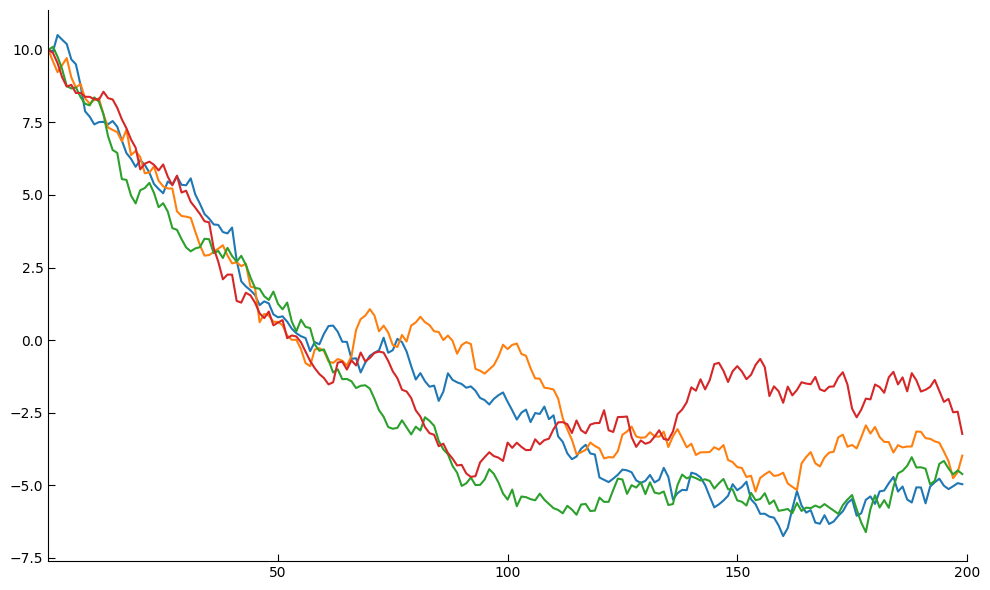

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_ou_process(theta, mu, sigma, X0, dt, N, num_paths):
    """
    Simulates multiple paths of an Ornstein-Uhlenbeck process.
    """
    X = np.zeros((N, num_paths))
    X[0, :] = X0
    
    Z = np.random.normal(0, 1, (N - 1, num_paths))
    
    for t in range(1, N):
        X[t, :] = X[t-1, :] + theta * (mu - X[t-1, :]) * dt + sigma * np.sqrt(dt) * Z[t-1, :]
        
    return X

# --- Parameters ---
num_paths = 4       
N = 200             
dt = 1.0            
X0 = 10.0           
mu = -5.0            
theta = 0.015        
sigma = 0.3         

# Generate the data
paths = simulate_ou_process(theta, mu, sigma, X0, dt, N, num_paths)
time_steps = np.arange(N)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 6))

for i in range(num_paths):
    # CHANGED: Use a solid line ('-') and remove the dot marker
    ax.plot(time_steps, paths[:, i], linestyle='-', linewidth=1.5)

ax.set_xlim(0, N)
ax.set_xticks([50, 100, 150, 200]) 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', direction='in', length=5)

plt.tight_layout()
plt.show()

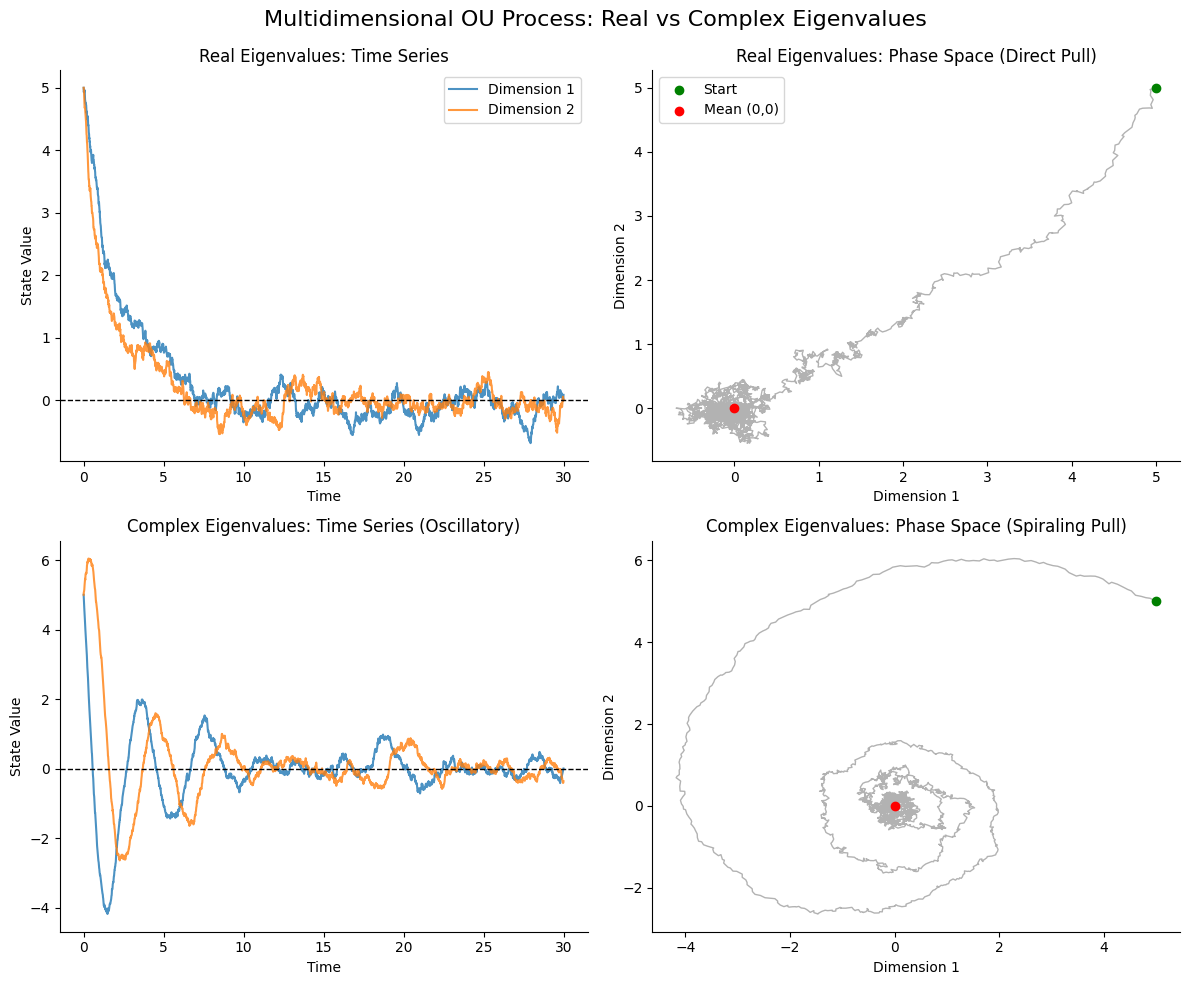

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_2d_ou(Gamma, mu, G, X0, dt, N):
    """
    Simulates a 2D Ornstein-Uhlenbeck process.
    dX_t = -Gamma @ (X_t - mu) dt + G @ dW_t
    """
    # Initialize array
    X = np.zeros((N, 2))
    X[0] = X0
    
    # Pre-generate noise for efficiency
    dW = np.random.normal(0, np.sqrt(dt), (N - 1, 2))
    
    # Euler-Maruyama integration
    for t in range(1, N):
        drift = -Gamma @ (X[t-1] - mu) * dt
        diffusion = G @ dW[t-1]
        X[t] = X[t-1] + drift + diffusion
        
    return X

# --- Common Parameters ---
N = 3000          # Number of time steps
dt = 0.01         # Time step size
X0 = np.array([5.0, 5.0])  # Start far from the mean to see the reversion path
mu = np.array([0.0, 0.0])  # Long-term mean at the origin
G = np.array([[0.3, 0.0],  # Volatility matrix (low noise to see the drift clearly)
              [0.0, 0.3]]) 
time = np.arange(N) * dt

# --- 1. Real Eigenvalues (Symmetric Drift Matrix) ---
# Eigenvalues are exactly 0.5 and 0.8 (purely real, stable pull)
Gamma_real = np.array([[0.5, 0.0], 
                       [0.0, 0.8]])

X_real = simulate_2d_ou(Gamma_real, mu, G, X0, dt, N)

# --- 2. Complex Eigenvalues (Asymmetric/Skew Drift Matrix) ---
# Adding off-diagonal elements of opposite signs creates rotation.
# Eigenvalues are 0.4 +/- 1.5j (real part > 0 ensures stability, imaginary causes oscillation)
Gamma_complex = np.array([[0.4, 1.5], 
                          [-1.5, 0.4]])

X_complex = simulate_2d_ou(Gamma_complex, mu, G, X0, dt, N)

# --- Plotting ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Multidimensional OU Process: Real vs Complex Eigenvalues', fontsize=16)

# Top Left: Real Eigenvalues - Time Series
axes[0, 0].plot(time, X_real[:, 0], label='Dimension 1', color='#1f77b4', alpha=0.8)
axes[0, 0].plot(time, X_real[:, 1], label='Dimension 2', color='#ff7f0e', alpha=0.8)
axes[0, 0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0, 0].set_title('Real Eigenvalues: Time Series')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('State Value')
axes[0, 0].legend()

# Top Right: Real Eigenvalues - Phase Space
axes[0, 1].plot(X_real[:, 0], X_real[:, 1], color='gray', alpha=0.6, linewidth=1)
axes[0, 1].scatter(X_real[0, 0], X_real[0, 1], color='green', zorder=5, label='Start')
axes[0, 1].scatter(0, 0, color='red', zorder=5, label='Mean (0,0)')
axes[0, 1].set_title('Real Eigenvalues: Phase Space (Direct Pull)')
axes[0, 1].set_xlabel('Dimension 1')
axes[0, 1].set_ylabel('Dimension 2')
axes[0, 1].legend()

# Bottom Left: Complex Eigenvalues - Time Series
axes[1, 0].plot(time, X_complex[:, 0], label='Dimension 1', color='#1f77b4', alpha=0.8)
axes[1, 0].plot(time, X_complex[:, 1], label='Dimension 2', color='#ff7f0e', alpha=0.8)
axes[1, 0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1, 0].set_title('Complex Eigenvalues: Time Series (Oscillatory)')
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('State Value')

# Bottom Right: Complex Eigenvalues - Phase Space
axes[1, 1].plot(X_complex[:, 0], X_complex[:, 1], color='gray', alpha=0.6, linewidth=1)
axes[1, 1].scatter(X_complex[0, 0], X_complex[0, 1], color='green', zorder=5, label='Start')
axes[1, 1].scatter(0, 0, color='red', zorder=5, label='Mean (0,0)')
axes[1, 1].set_title('Complex Eigenvalues: Phase Space (Spiraling Pull)')
axes[1, 1].set_xlabel('Dimension 1')
axes[1, 1].set_ylabel('Dimension 2')

# Formatting cleanup
for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

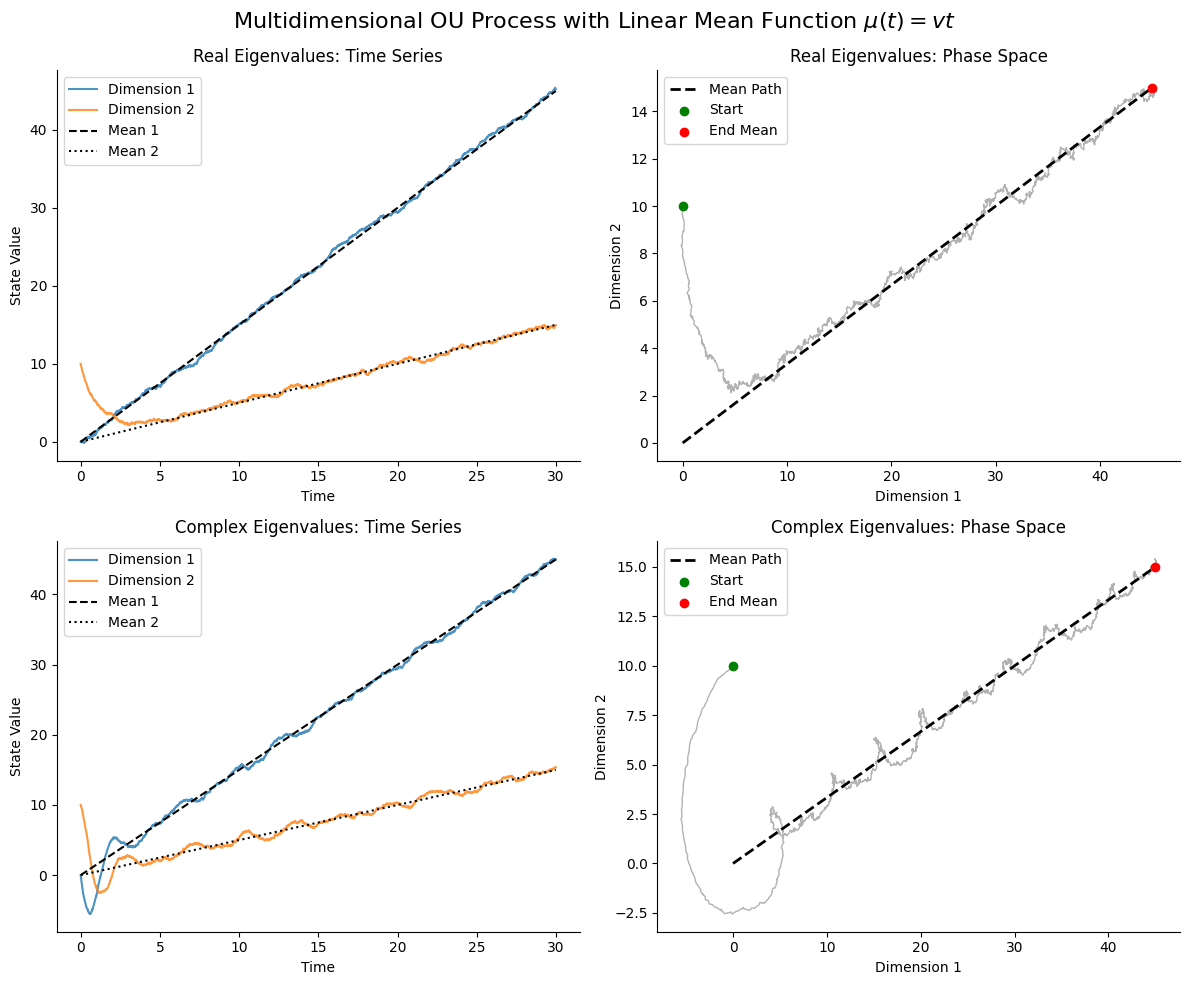

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_2d_ou_linear_mean(Gamma, v, G, X0, dt, N):
    """
    Simulates a 2D OU process with a linear shifting mean mu(t) = v * t.
    dX_t = [v - Gamma @ (X_t - v * t)] dt + G @ dW_t
    """
    X = np.zeros((N, 2))
    X[0] = X0
    
    # Pre-generate noise
    dW = np.random.normal(0, np.sqrt(dt), (N - 1, 2))
    time = np.arange(N) * dt
    
    # Euler-Maruyama integration
    for t in range(1, N):
        # The drift includes the forward momentum 'v' and the reversion pull
        drift = (v - Gamma @ (X[t-1] - v * time[t-1])) * dt
        diffusion = G @ dW[t-1]
        X[t] = X[t-1] + drift + diffusion
        
    return X, time

# --- Parameters ---
N = 3000
dt = 0.01
X0 = np.array([0.0, 10.0]) # Start off the mean path to see the pull
v = np.array([1.5, 0.5])   # The linear slope/velocity of the mean function
G = np.array([[0.4, 0.0],  # Volatility matrix
              [0.0, 0.4]]) 

# --- 1. Real Eigenvalues ---
Gamma_real = np.array([[0.8, 0.0], 
                       [0.0, 0.8]])
X_real, time = simulate_2d_ou_linear_mean(Gamma_real, v, G, X0, dt, N)

# --- 2. Complex Eigenvalues ---
Gamma_complex = np.array([[0.8, 2.0], 
                          [-2.0, 0.8]])
X_complex, _ = simulate_2d_ou_linear_mean(Gamma_complex, v, G, X0, dt, N)

# Calculate the theoretical mean trajectory: mu(t) = v * t
mean_trajectory = np.outer(time, v)

# --- Plotting ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Multidimensional OU Process with Linear Mean Function $\mu(t) = vt$', fontsize=16)

# Helper function to plot time series
def plot_time_series(ax, X, title):
    ax.plot(time, X[:, 0], label='Dimension 1', color='#1f77b4', alpha=0.8)
    ax.plot(time, X[:, 1], label='Dimension 2', color='#ff7f0e', alpha=0.8)
    ax.plot(time, mean_trajectory[:, 0], color='black', linestyle='--', linewidth=1.5, label='Mean 1')
    ax.plot(time, mean_trajectory[:, 1], color='black', linestyle=':', linewidth=1.5, label='Mean 2')
    ax.set_title(title)
    ax.set_xlabel('Time')
    ax.set_ylabel('State Value')
    ax.legend()

# Helper function to plot phase space
def plot_phase_space(ax, X, title):
    ax.plot(X[:, 0], X[:, 1], color='gray', alpha=0.6, linewidth=1)
    ax.plot(mean_trajectory[:, 0], mean_trajectory[:, 1], color='black', linestyle='--', linewidth=2, label='Mean Path')
    ax.scatter(X[0, 0], X[0, 1], color='green', zorder=5, label='Start')
    ax.scatter(mean_trajectory[-1, 0], mean_trajectory[-1, 1], color='red', zorder=5, label='End Mean')
    ax.set_title(title)
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    ax.legend()

# Top Row: Real Eigenvalues
plot_time_series(axes[0, 0], X_real, 'Real Eigenvalues: Time Series')
plot_phase_space(axes[0, 1], X_real, 'Real Eigenvalues: Phase Space')

# Bottom Row: Complex Eigenvalues
plot_time_series(axes[1, 0], X_complex, 'Complex Eigenvalues: Time Series')
plot_phase_space(axes[1, 1], X_complex, 'Complex Eigenvalues: Phase Space')

for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

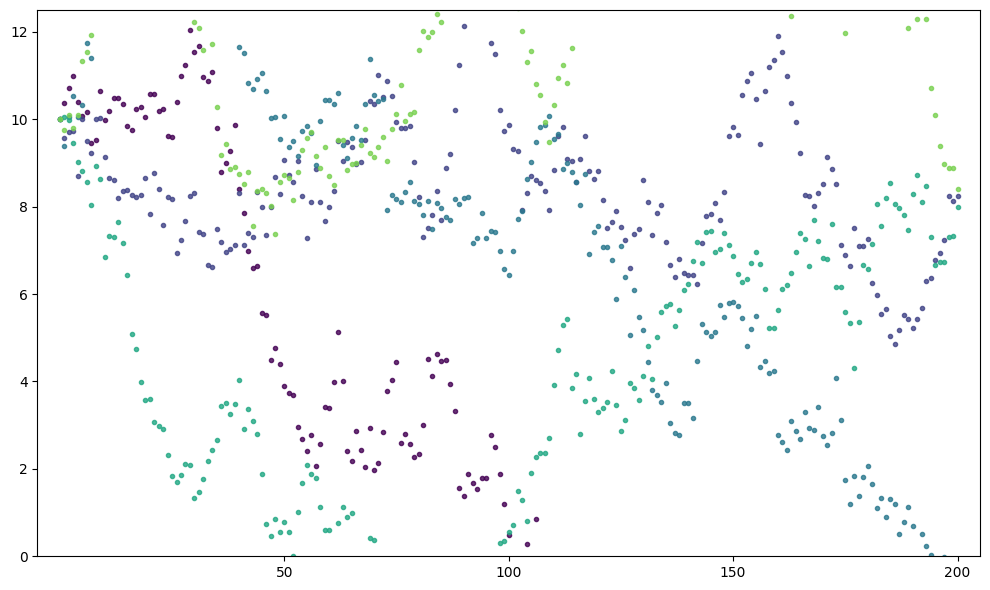

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# --- Parameters ---
num_paths = 5       # Number of individual random walks to simulate
num_steps = 200     # Total steps per path (aligns with x-axis)
start_y = 10        # Common starting state value (aligns with y-axis origin)
drift = -0.03       # Overall expected downward trend per step
noise_level = 0.6    # Magnitude of random fluctuations (standard deviation) per step

# --- Simulate Paths ---
# Initialize paths array for efficiency, including initial state at step 0
# numpy's cumsum will be used to efficiently calculate the paths
# size=(num_paths, num_steps) will generate all random values in one go
steps = np.random.normal(loc=drift, scale=noise_level, size=(num_paths, num_steps))
paths = np.cumsum(steps, axis=1) + start_y

# prepend the starting point for step 0 for each path for a complete representation
initial_states = np.full((num_paths, 1), start_y)
paths = np.hstack((initial_states, paths))

# Time steps for x-axis (0 to num_steps)
time_steps = np.arange(num_steps + 1)

# --- Plotting ---
plt.figure(figsize=(10, 6)) # Adjust figure size for better visual presentation

# Loop through each path and plot using colored dots without lines
# Using a colormap (cm.viridis) ensures distinct colors for each path
for i in range(num_paths):
    plt.plot(time_steps, paths[i, :], marker='o', linestyle='None', markersize=3, 
             color=cm.viridis(i / num_paths), alpha=0.8, label=f'Path {i+1}')

# Set specific axes ticks and range to match the image
plt.xticks([50, 100, 150, 200]) # Tick marks at intervals of 50
plt.yticks(np.arange(0, 14, 2)) # Tick marks every 2 units from 0 to 12
plt.ylim(0, 12.5) # Extend slightly beyond 12 for visual padding with noise
plt.xlim(-5, 205) # Extend slightly beyond 0-200 for visual padding with dots

# Additional formatting for clarity
plt.tight_layout()
# In the original image, there were no grid lines or labels.
# You could potentially add them for better interpretation, but let's keep it close for now.
# plt.grid(True)
# plt.xlabel('Time Steps')
# plt.ylabel('State Value')

# To hide the top and right spines as well as some ticks and get the exact original look:
# plt.gca().spines['top'].set_visible(False)
# plt.gca().spines['right'].set_visible(False)
# plt.tick_params(axis='both', which='both', bottom=True, left=True, labelbottom=True, labelleft=True)

plt.show()

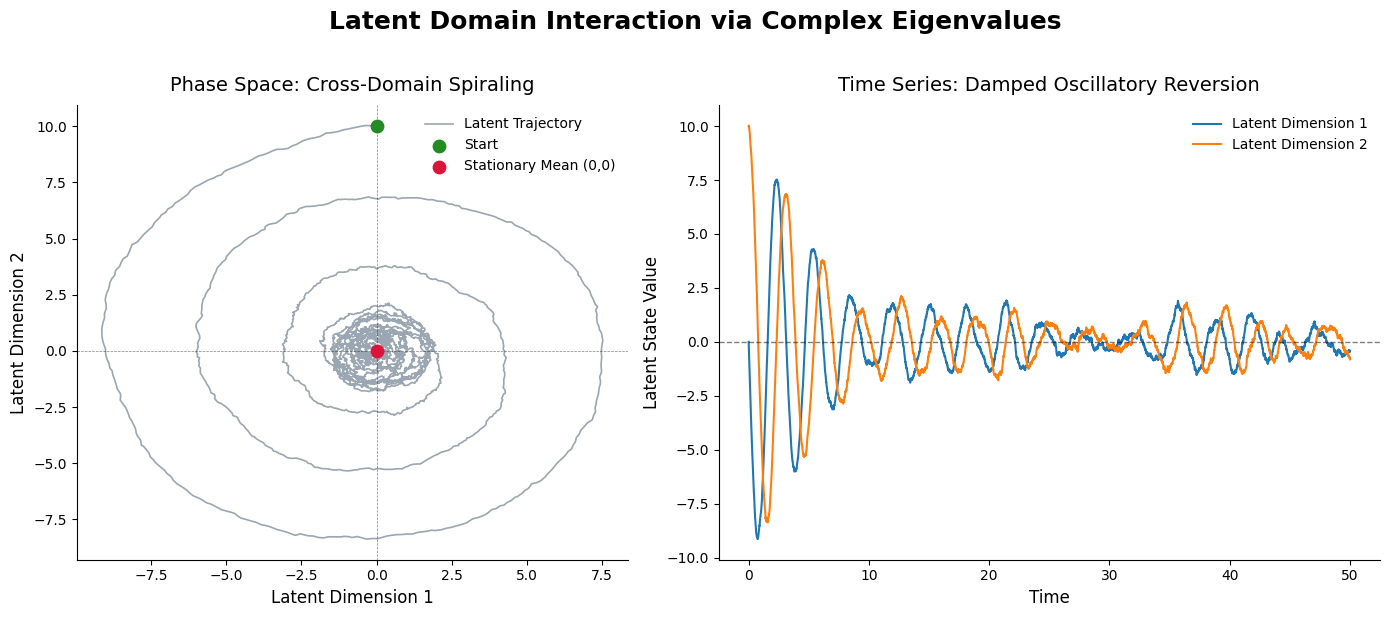

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_2d_ou_complex(Gamma, mu, G, X0, dt, N):
    """
    Simulates a 2D OU process with a complex eigenvalue drift matrix.
    """
    X = np.zeros((N, 2))
    X[0] = X0
    
    # Pre-generate noise
    dW = np.random.normal(0, np.sqrt(dt), (N - 1, 2))
    
    # Euler-Maruyama integration
    for t in range(1, N):
        drift = -Gamma @ (X[t-1] - mu) * dt
        diffusion = G @ dW[t-1]
        X[t] = X[t-1] + drift + diffusion
        
    return X

# --- Parameters for a "Strong Case" ---
N = 5000                   # Number of time steps (longer to show full spiral)
dt = 0.01                  # Time step size
X0 = np.array([0.0, 10.0]) # Start far from the mean to emphasize the path
mu = np.array([0.0, 0.0])  # Stationary mean at the origin

# Drift matrix with complex eigenvalues
# The small diagonal values (0.15) create a slow, gradual pull to the center.
# The large off-diagonal values (+/- 2.0) create strong cross-domain rotation.
Gamma = np.array([[0.15, 2.0], 
                  [-2.0, 0.15]])

# Low volatility so the deterministic spiral isn't obscured by noise
G = np.array([[0.35, 0.0],  
              [0.0, 0.35]])

# Simulate the process
X = simulate_2d_ou_complex(Gamma, mu, G, X0, dt, N)
time = np.arange(N) * dt

# --- Plotting for Presentation ---
# Using a slightly wider figure to accommodate side-by-side plots nicely on a slide
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1.2]})
fig.suptitle('Latent Domain Interaction via Complex Eigenvalues', fontsize=18, fontweight='bold', y=1.02)

# Left Plot: Phase Space (The Spiral)
ax1.plot(X[:, 0], X[:, 1], color='slategray', alpha=0.7, linewidth=1.2, label='Latent Trajectory')
ax1.scatter(X0[0], X0[1], color='forestgreen', s=80, zorder=5, label='Start')
ax1.scatter(mu[0], mu[1], color='crimson', s=80, zorder=5, label='Stationary Mean (0,0)')

ax1.set_title('Phase Space: Cross-Domain Spiraling', fontsize=14, pad=10)
ax1.set_xlabel('Latent Dimension 1', fontsize=12)
ax1.set_ylabel('Latent Dimension 2', fontsize=12)

# Add faint axes lines to center the spiral visually
ax1.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
ax1.axvline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right', frameon=False)

# Right Plot: Time Series (Damped Oscillation)
ax2.plot(time, X[:, 0], label='Latent Dimension 1', color='#1f77b4', linewidth=1.5)
ax2.plot(time, X[:, 1], label='Latent Dimension 2', color='#ff7f0e', linewidth=1.5)

ax2.set_title('Time Series: Damped Oscillatory Reversion', fontsize=14, pad=10)
ax2.set_xlabel('Time', fontsize=12)
ax2.set_ylabel('Latent State Value', fontsize=12)
ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.legend(loc='upper right', frameon=False)

# Clean up formatting for a professional slide look
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()

# Save the figure with high DPI for slide clarity
plt.savefig('complex_eigenvalue_interaction.png', dpi=300, bbox_inches='tight')
plt.show()

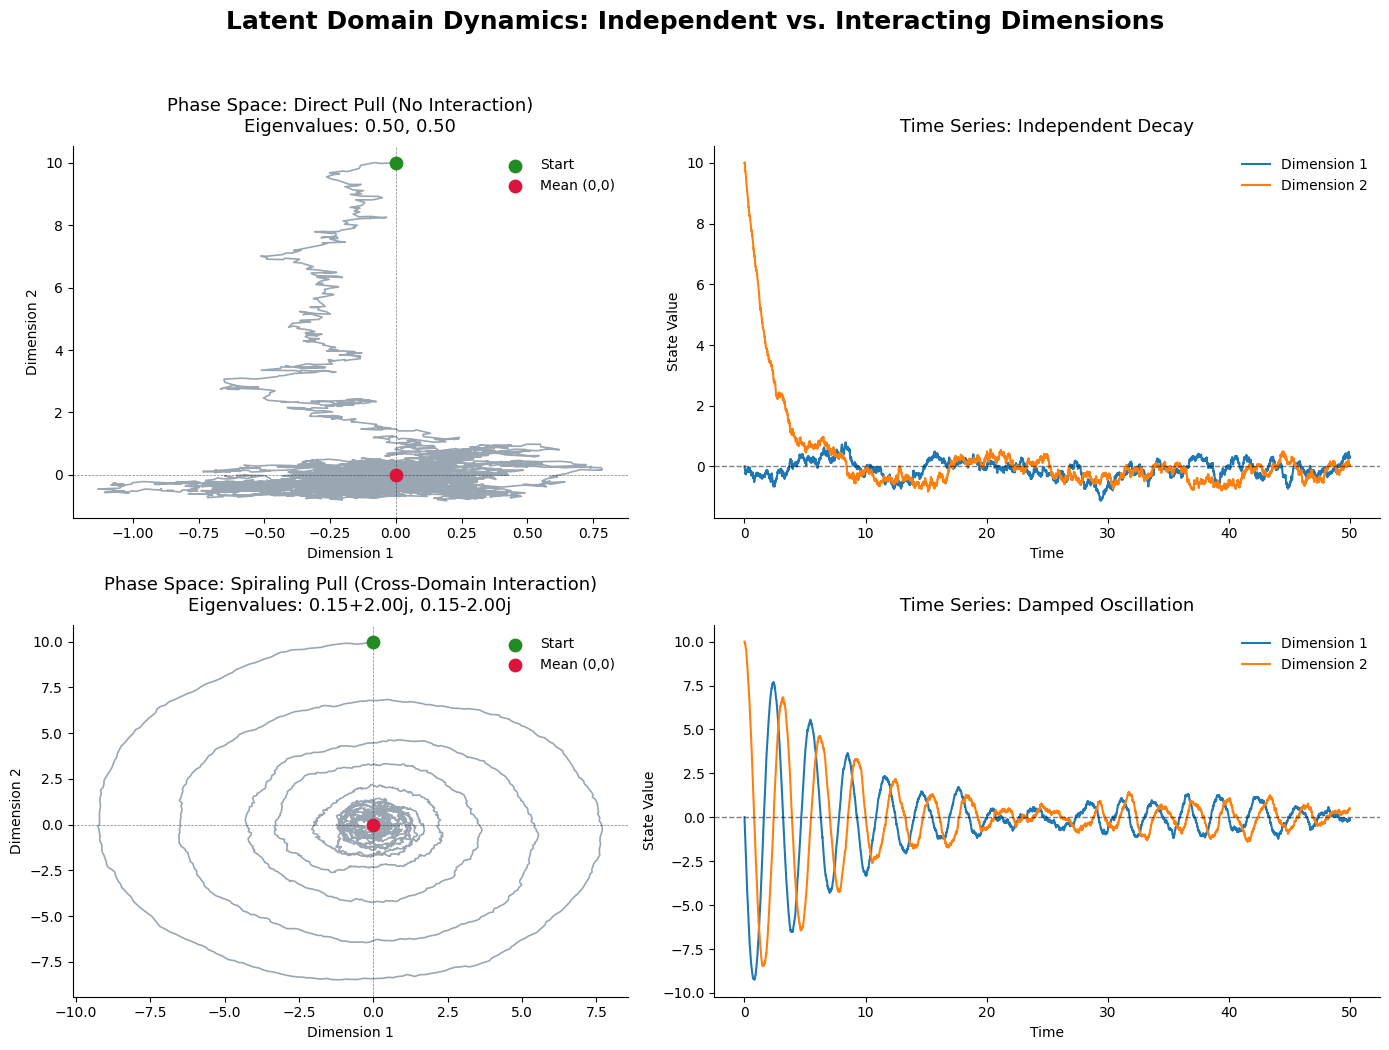

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_2d_ou(Gamma, mu, G, X0, dt, N):
    """
    Simulates a 2D Ornstein-Uhlenbeck process given a drift matrix Gamma.
    """
    X = np.zeros((N, 2))
    X[0] = X0
    
    # Pre-generate noise
    dW = np.random.normal(0, np.sqrt(dt), (N - 1, 2))
    
    # Euler-Maruyama integration
    for t in range(1, N):
        drift = -Gamma @ (X[t-1] - mu) * dt
        diffusion = G @ dW[t-1]
        X[t] = X[t-1] + drift + diffusion
        
    return X

# --- Shared Parameters ---
N = 5000                   # Number of time steps
dt = 0.01                  # Time step size
X0 = np.array([0.0, 10.0]) # Start far from the mean 
mu = np.array([0.0, 0.0])  # Stationary mean at the origin
G = np.array([[0.35, 0.0], # Low volatility 
              [0.0, 0.35]])
time = np.arange(N) * dt

# --- 1. Independent Domains (Real Eigenvalues) ---
# Symmetric matrix: pure exponential decay, no cross-domain interaction
Gamma_real = np.array([[0.5, 0.0], 
                       [0.0, 0.5]])
X_real = simulate_2d_ou(Gamma_real, mu, G, X0, dt, N)
eig_real, _ = np.linalg.eig(Gamma_real)

# --- 2. Interacting Domains (Complex Eigenvalues) ---
# Asymmetric matrix: strong cross-domain rotation, slow exponential decay
Gamma_complex = np.array([[0.15, 2.0], 
                          [-2.0, 0.15]])
X_complex = simulate_2d_ou(Gamma_complex, mu, G, X0, dt, N)
eig_comp, _ = np.linalg.eig(Gamma_complex)

# --- Plotting ---
fig, axes = plt.subplots(2, 2, figsize=(14, 11), gridspec_kw={'width_ratios': [1, 1.2]})
fig.suptitle('Latent Domain Dynamics: Independent vs. Interacting Dimensions', fontsize=18, fontweight='bold', y=0.98)

# --- 1. Update the Helper Function ---
def plot_phase_space(ax, X, title, eigenvalues):
    ax.plot(X[:, 0], X[:, 1], color='slategray', alpha=0.7, linewidth=1.2)
    ax.scatter(X[0, 0], X[0, 1], color='forestgreen', s=80, zorder=5, label='Start')
    ax.scatter(mu[0], mu[1], color='crimson', s=80, zorder=5, label='Mean (0,0)')
    
    # FIX: Removed the ':.2f' so it just accepts the strings we pass it
    ax.set_title(f"{title}\nEigenvalues: {eigenvalues[0]}, {eigenvalues[1]}", fontsize=13, pad=10)
    
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.axvline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', frameon=False)



def plot_time_series(ax, X, title):
    ax.plot(time, X[:, 0], label='Dimension 1', color='#1f77b4', linewidth=1.5)
    ax.plot(time, X[:, 1], label='Dimension 2', color='#ff7f0e', linewidth=1.5)
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel('Time')
    ax.set_ylabel('State Value')
    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.legend(loc='upper right', frameon=False)

# --- 2. Update the Plotting Calls ---
# Top Row: Real Eigenvalues
# FIX: Pre-format the real eigenvalues into strings before passing them
eig_real_str = [f"{e:.2f}" for e in eig_real]
plot_phase_space(axes[0, 0], X_real, 'Phase Space: Direct Pull (No Interaction)', eig_real_str)
plot_time_series(axes[0, 1], X_real, 'Time Series: Independent Decay')

# Bottom Row: Complex Eigenvalues
# (This remains the same, as it was already creating strings)
eig_comp_str = [f"{e.real:.2f}{e.imag:+.2f}j" for e in eig_comp]
plot_phase_space(axes[1, 0], X_complex, 'Phase Space: Spiraling Pull (Cross-Domain Interaction)', eig_comp_str)
plot_time_series(axes[1, 1], X_complex, 'Time Series: Damped Oscillation')


# Formatting cleanup
for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('ou_eigenvalue_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

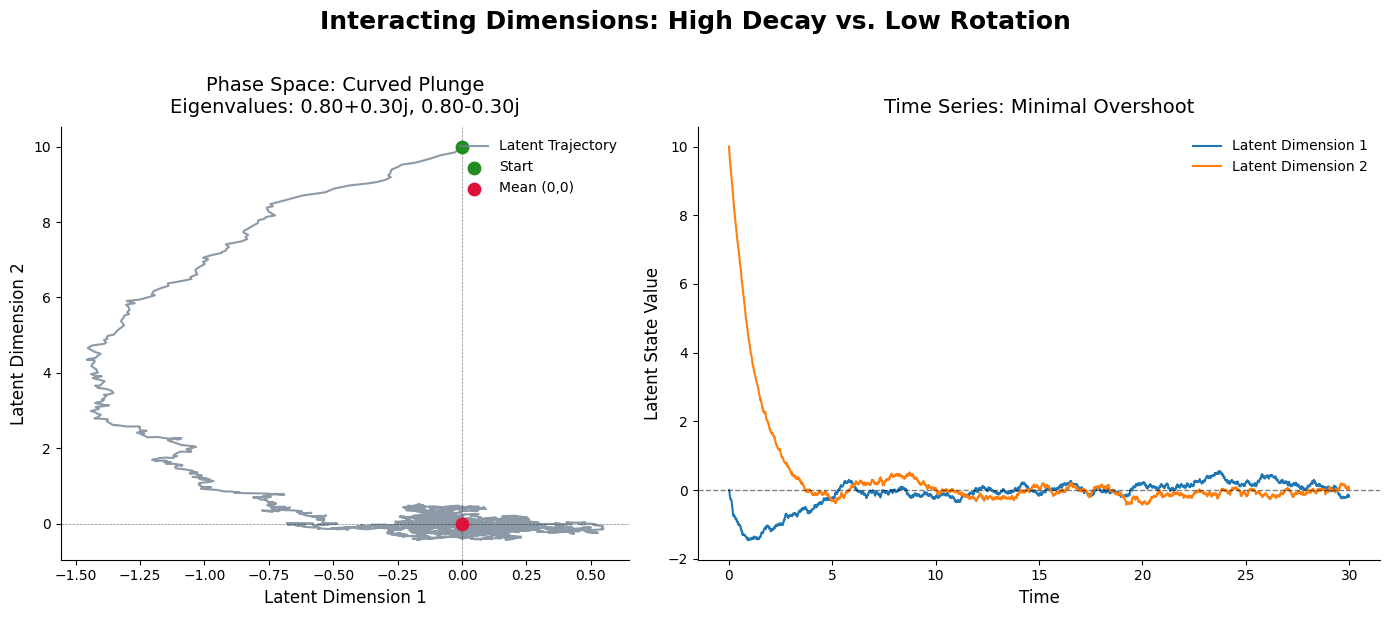

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_2d_ou_monotonic_complex(Gamma, mu, G, X0, dt, N):
    """
    Simulates a 2D OU process with a complex eigenvalue drift matrix
    tuned to avoid heavy oscillation.
    """
    X = np.zeros((N, 2))
    X[0] = X0
    
    # Pre-generate noise
    dW = np.random.normal(0, np.sqrt(dt), (N - 1, 2))
    
    # Euler-Maruyama integration
    for t in range(1, N):
        drift = -Gamma @ (X[t-1] - mu) * dt
        diffusion = G @ dW[t-1]
        X[t] = X[t-1] + drift + diffusion
        
    return X

# --- Parameters ---
N = 3000                   # Number of time steps
dt = 0.01                  # Time step size
X0 = np.array([0.0, 10.0]) # Start far from the mean 
mu = np.array([0.0, 0.0])  # Stationary mean at the origin

# --- The "Nearly Monotonic" Complex Drift Matrix ---
# High diagonal = Fast decay
# Low off-diagonal = Slow rotation
Gamma = np.array([[0.8, 0.3], 
                  [-0.3, 0.8]])

# Low volatility 
G = np.array([[0.2, 0.0],  
              [0.0, 0.2]])

# Simulate the process
X = simulate_2d_ou_monotonic_complex(Gamma, mu, G, X0, dt, N)
time = np.arange(N) * dt
eigenvalues, _ = np.linalg.eig(Gamma)
eig_str = [f"{e.real:.2f}{e.imag:+.2f}j" for e in eigenvalues]

# --- Plotting for Presentation ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1.2]})
fig.suptitle('Interacting Dimensions: High Decay vs. Low Rotation', fontsize=18, fontweight='bold', y=1.02)

# Left Plot: Phase Space (The Swoop)
ax1.plot(X[:, 0], X[:, 1], color='slategray', alpha=0.8, linewidth=1.5, label='Latent Trajectory')
ax1.scatter(X0[0], X0[1], color='forestgreen', s=80, zorder=5, label='Start')
ax1.scatter(mu[0], mu[1], color='crimson', s=80, zorder=5, label='Mean (0,0)')

ax1.set_title(f"Phase Space: Curved Plunge\nEigenvalues: {eig_str[0]}, {eig_str[1]}", fontsize=14, pad=10)
ax1.set_xlabel('Latent Dimension 1', fontsize=12)
ax1.set_ylabel('Latent Dimension 2', fontsize=12)
ax1.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
ax1.axvline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right', frameon=False)

# Right Plot: Time Series (Nearly Monotonic Decay)
ax2.plot(time, X[:, 0], label='Latent Dimension 1', color='#1f77b4', linewidth=1.5)
ax2.plot(time, X[:, 1], label='Latent Dimension 2', color='#ff7f0e', linewidth=1.5)

ax2.set_title('Time Series: Minimal Overshoot', fontsize=14, pad=10)
ax2.set_xlabel('Time', fontsize=12)
ax2.set_ylabel('Latent State Value', fontsize=12)
ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.legend(loc='upper right', frameon=False)

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()
plt.savefig('monotonic_complex_eigenvalues.png', dpi=300, bbox_inches='tight')
plt.show()

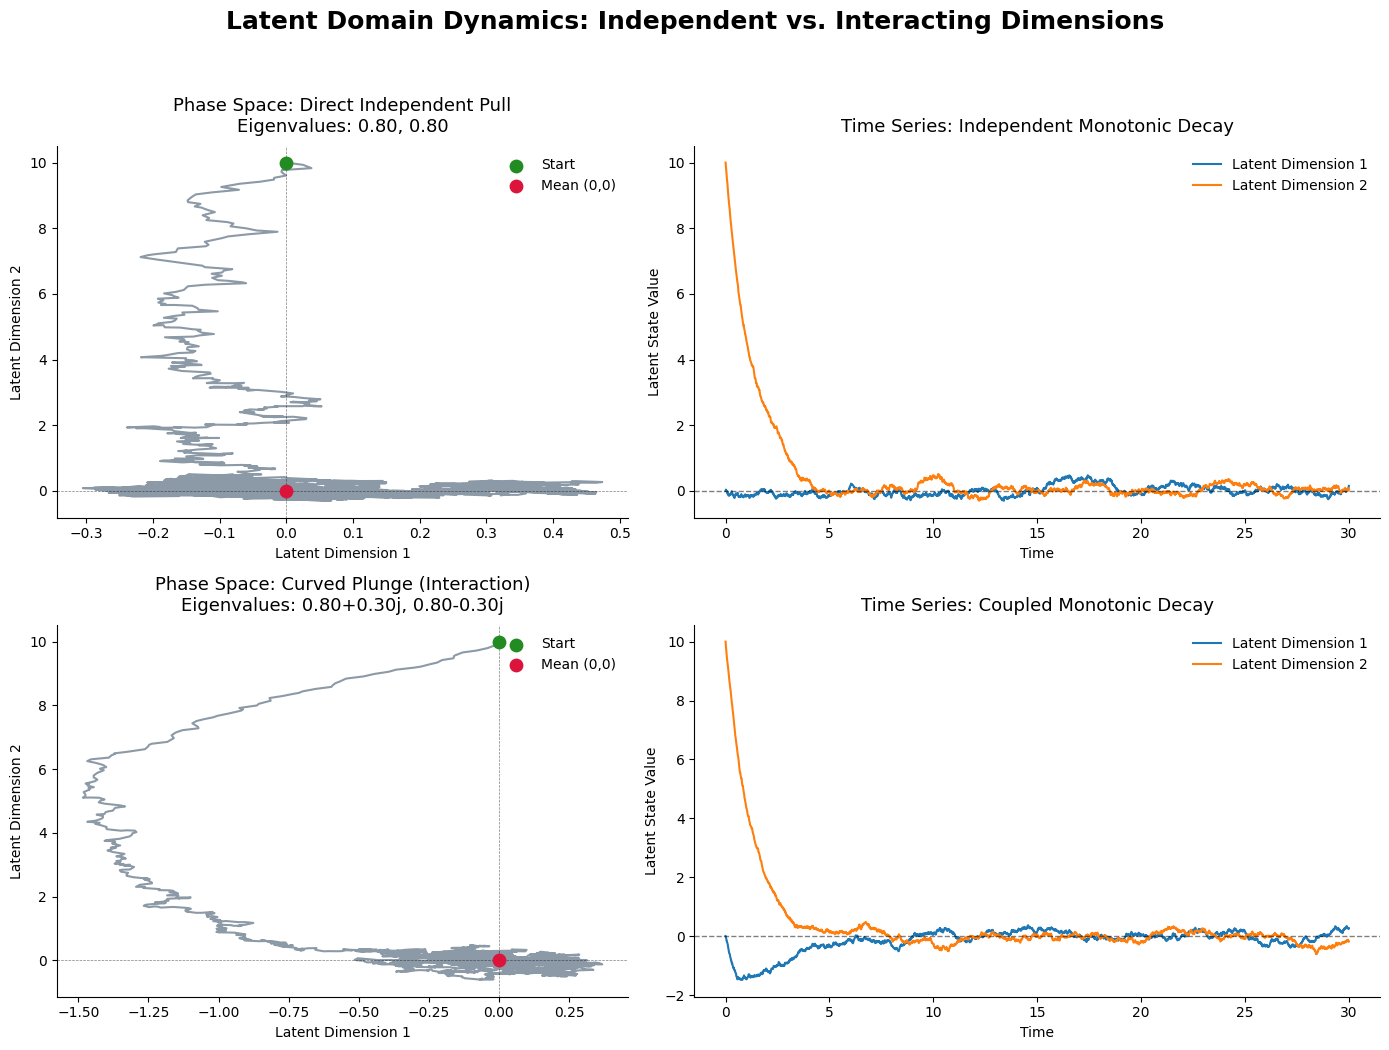

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_2d_ou(Gamma, mu, G, X0, dt, N):
    """
    Simulates a 2D Ornstein-Uhlenbeck process.
    """
    X = np.zeros((N, 2))
    X[0] = X0
    
    # Pre-generate noise
    dW = np.random.normal(0, np.sqrt(dt), (N - 1, 2))
    
    # Euler-Maruyama integration
    for t in range(1, N):
        drift = -Gamma @ (X[t-1] - mu) * dt
        diffusion = G @ dW[t-1]
        X[t] = X[t-1] + drift + diffusion
        
    return X

# --- Shared Parameters ---
N = 3000                   # Number of time steps
dt = 0.01                  # Time step size
X0 = np.array([0.0, 10.0]) # Start far from the mean 
mu = np.array([0.0, 0.0])  # Stationary mean at the origin
G = np.array([[0.2, 0.0],  # Low volatility to see the curve clearly
              [0.0, 0.2]])
time = np.arange(N) * dt

# --- 1. Real Eigenvalues (Independent Domains) ---
# High diagonal = Fast decay
# Zero off-diagonal = No rotation
Gamma_real = np.array([[0.8, 0.0], 
                       [0.0, 0.8]])
X_real = simulate_2d_ou(Gamma_real, mu, G, X0, dt, N)
eig_real = np.linalg.eigvals(Gamma_real)
eig_real_str = [f"{e.real:.2f}" for e in eig_real]

# --- 2. Complex Eigenvalues (Interacting Domains - Monotonic) ---
# High diagonal = Fast decay
# Low off-diagonal = Slow rotation (creates a swoop, not a full spiral)
Gamma_complex = np.array([[0.8, 0.3], 
                          [-0.3, 0.8]])
X_complex = simulate_2d_ou(Gamma_complex, mu, G, X0, dt, N)
eig_comp = np.linalg.eigvals(Gamma_complex)
eig_comp_str = [f"{e.real:.2f}{e.imag:+.2f}j" for e in eig_comp]

# --- Plotting ---
fig, axes = plt.subplots(2, 2, figsize=(14, 11), gridspec_kw={'width_ratios': [1, 1.2]})
fig.suptitle('Latent Domain Dynamics: Independent vs. Interacting Dimensions', fontsize=18, fontweight='bold', y=0.98)

# --- Helper Plotting Functions ---
def plot_phase_space(ax, X, title, eigenvalues):
    ax.plot(X[:, 0], X[:, 1], color='slategray', alpha=0.8, linewidth=1.5)
    ax.scatter(X[0, 0], X[0, 1], color='forestgreen', s=80, zorder=5, label='Start')
    ax.scatter(mu[0], mu[1], color='crimson', s=80, zorder=5, label='Mean (0,0)')
    ax.set_title(f"{title}\nEigenvalues: {eigenvalues[0]}, {eigenvalues[1]}", fontsize=13, pad=10)
    ax.set_xlabel('Latent Dimension 1')
    ax.set_ylabel('Latent Dimension 2')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.axvline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', frameon=False)

def plot_time_series(ax, X, title):
    ax.plot(time, X[:, 0], label='Latent Dimension 1', color='#1f77b4', linewidth=1.5)
    ax.plot(time, X[:, 1], label='Latent Dimension 2', color='#ff7f0e', linewidth=1.5)
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel('Time')
    ax.set_ylabel('Latent State Value')
    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.legend(loc='upper right', frameon=False)

# --- Top Row: Real Eigenvalues ---
plot_phase_space(axes[0, 0], X_real, 'Phase Space: Direct Independent Pull', eig_real_str)
plot_time_series(axes[0, 1], X_real, 'Time Series: Independent Monotonic Decay')

# --- Bottom Row: Complex Eigenvalues ---
plot_phase_space(axes[1, 0], X_complex, 'Phase Space: Curved Plunge (Interaction)', eig_comp_str)
plot_time_series(axes[1, 1], X_complex, 'Time Series: Coupled Monotonic Decay')

# Formatting cleanup
for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('monotonic_comparison_eigenvalues.png', dpi=300, bbox_inches='tight')
plt.show()

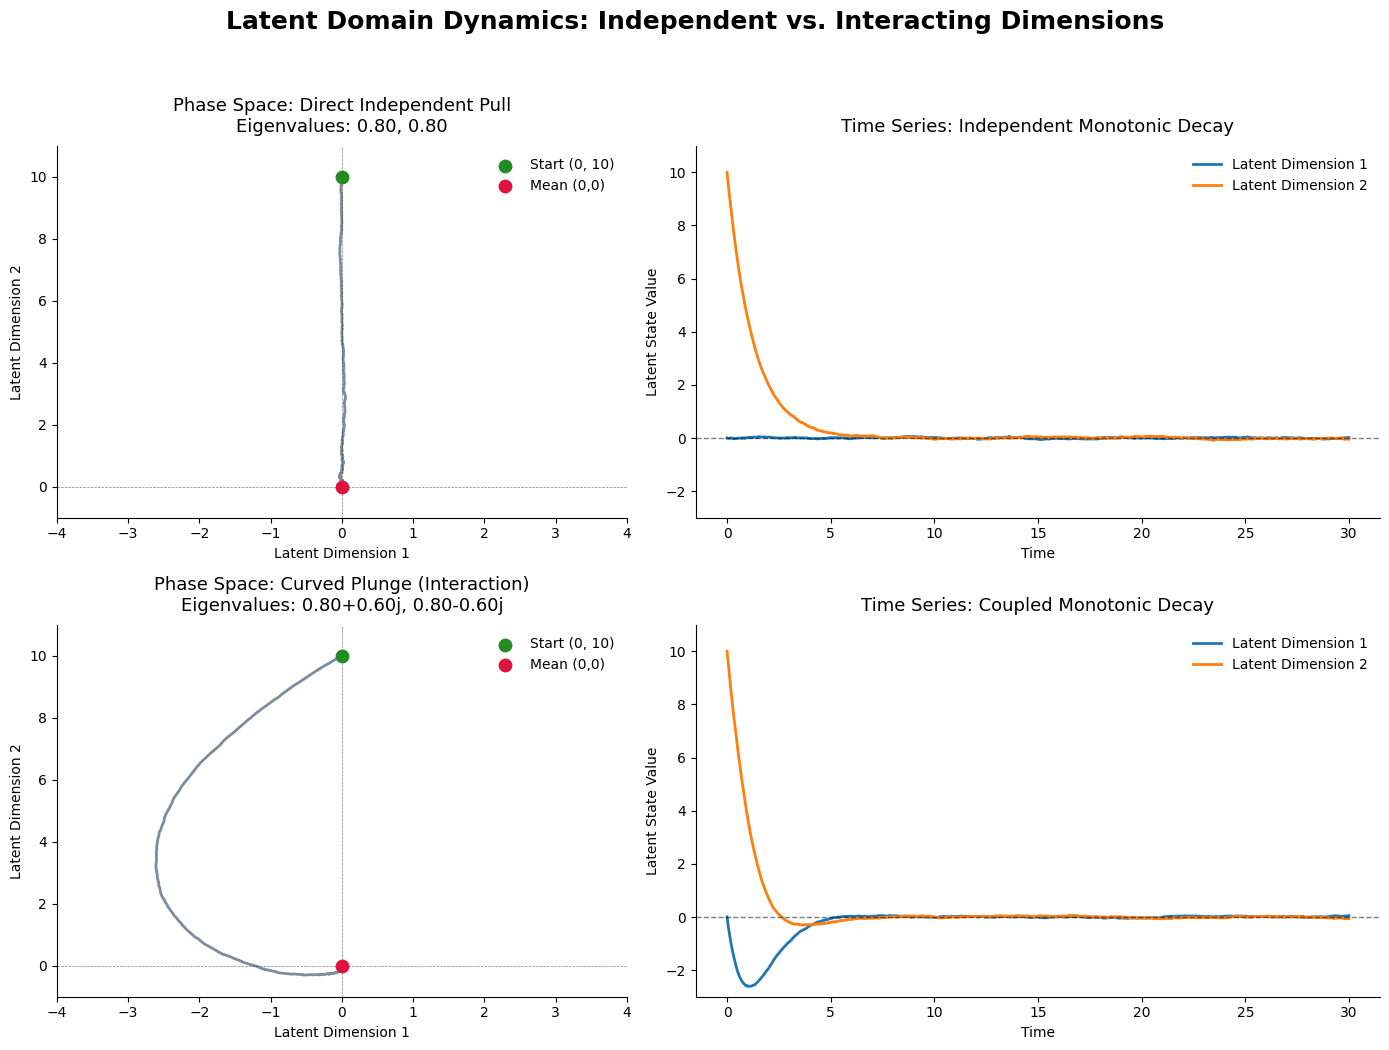

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_2d_ou(Gamma, mu, G, X0, dt, N):
    X = np.zeros((N, 2))
    X[0] = X0
    dW = np.random.normal(0, np.sqrt(dt), (N - 1, 2))
    for t in range(1, N):
        drift = -Gamma @ (X[t-1] - mu) * dt
        diffusion = G @ dW[t-1]
        X[t] = X[t-1] + drift + diffusion
    return X

# --- Shared Parameters ---
N = 3000                   
dt = 0.01                  
X0 = np.array([0.0, 10.0]) 
mu = np.array([0.0, 0.0])  

# 1. DRASTICALLY lowered noise to show the pure mathematical paths
G = np.array([[0.03, 0.0],  
              [0.0, 0.03]])
time = np.arange(N) * dt

# --- 1. Real Eigenvalues (Independent) ---
Gamma_real = np.array([[0.8, 0.0], 
                       [0.0, 0.8]])
X_real = simulate_2d_ou(Gamma_real, mu, G, X0, dt, N)
eig_real = np.linalg.eigvals(Gamma_real)
eig_real_str = [f"{e.real:.2f}" for e in eig_real]

# --- 2. Complex Eigenvalues (Interacting - Monotonic) ---
# 2. Increased off-diagonal from 0.3 to 0.6 for a wider swoop
Gamma_complex = np.array([[0.8, 0.6], 
                          [-0.6, 0.8]])
X_complex = simulate_2d_ou(Gamma_complex, mu, G, X0, dt, N)
eig_comp = np.linalg.eigvals(Gamma_complex)
eig_comp_str = [f"{e.real:.2f}{e.imag:+.2f}j" for e in eig_comp]

# --- Plotting ---
fig, axes = plt.subplots(2, 2, figsize=(14, 11), gridspec_kw={'width_ratios': [1, 1.2]})
fig.suptitle('Latent Domain Dynamics: Independent vs. Interacting Dimensions', fontsize=18, fontweight='bold', y=0.98)

def plot_phase_space(ax, X, title, eigenvalues):
    ax.plot(X[:, 0], X[:, 1], color='slategray', alpha=0.9, linewidth=2.0)
    ax.scatter(X[0, 0], X[0, 1], color='forestgreen', s=80, zorder=5, label='Start (0, 10)')
    ax.scatter(mu[0], mu[1], color='crimson', s=80, zorder=5, label='Mean (0,0)')
    ax.set_title(f"{title}\nEigenvalues: {eigenvalues[0]}, {eigenvalues[1]}", fontsize=13, pad=10)
    ax.set_xlabel('Latent Dimension 1')
    ax.set_ylabel('Latent Dimension 2')
    
    # 3. CRITICAL FIX: Hardcode X-axis limits so both plots are identically scaled
    ax.set_xlim(-4, 4) 
    ax.set_ylim(-1, 11)
    
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.axvline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', frameon=False)

def plot_time_series(ax, X, title):
    ax.plot(time, X[:, 0], label='Latent Dimension 1', color='#1f77b4', linewidth=2.0)
    ax.plot(time, X[:, 1], label='Latent Dimension 2', color='#ff7f0e', linewidth=2.0)
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel('Time')
    ax.set_ylabel('Latent State Value')
    ax.set_ylim(-3, 11) # Lock Y-axis for time series too
    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.legend(loc='upper right', frameon=False)

# Top Row: Real
plot_phase_space(axes[0, 0], X_real, 'Phase Space: Direct Independent Pull', eig_real_str)
plot_time_series(axes[0, 1], X_real, 'Time Series: Independent Monotonic Decay')

# Bottom Row: Complex
plot_phase_space(axes[1, 0], X_complex, 'Phase Space: Curved Plunge (Interaction)', eig_comp_str)
plot_time_series(axes[1, 1], X_complex, 'Time Series: Coupled Monotonic Decay')

for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('monotonic_comparison_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

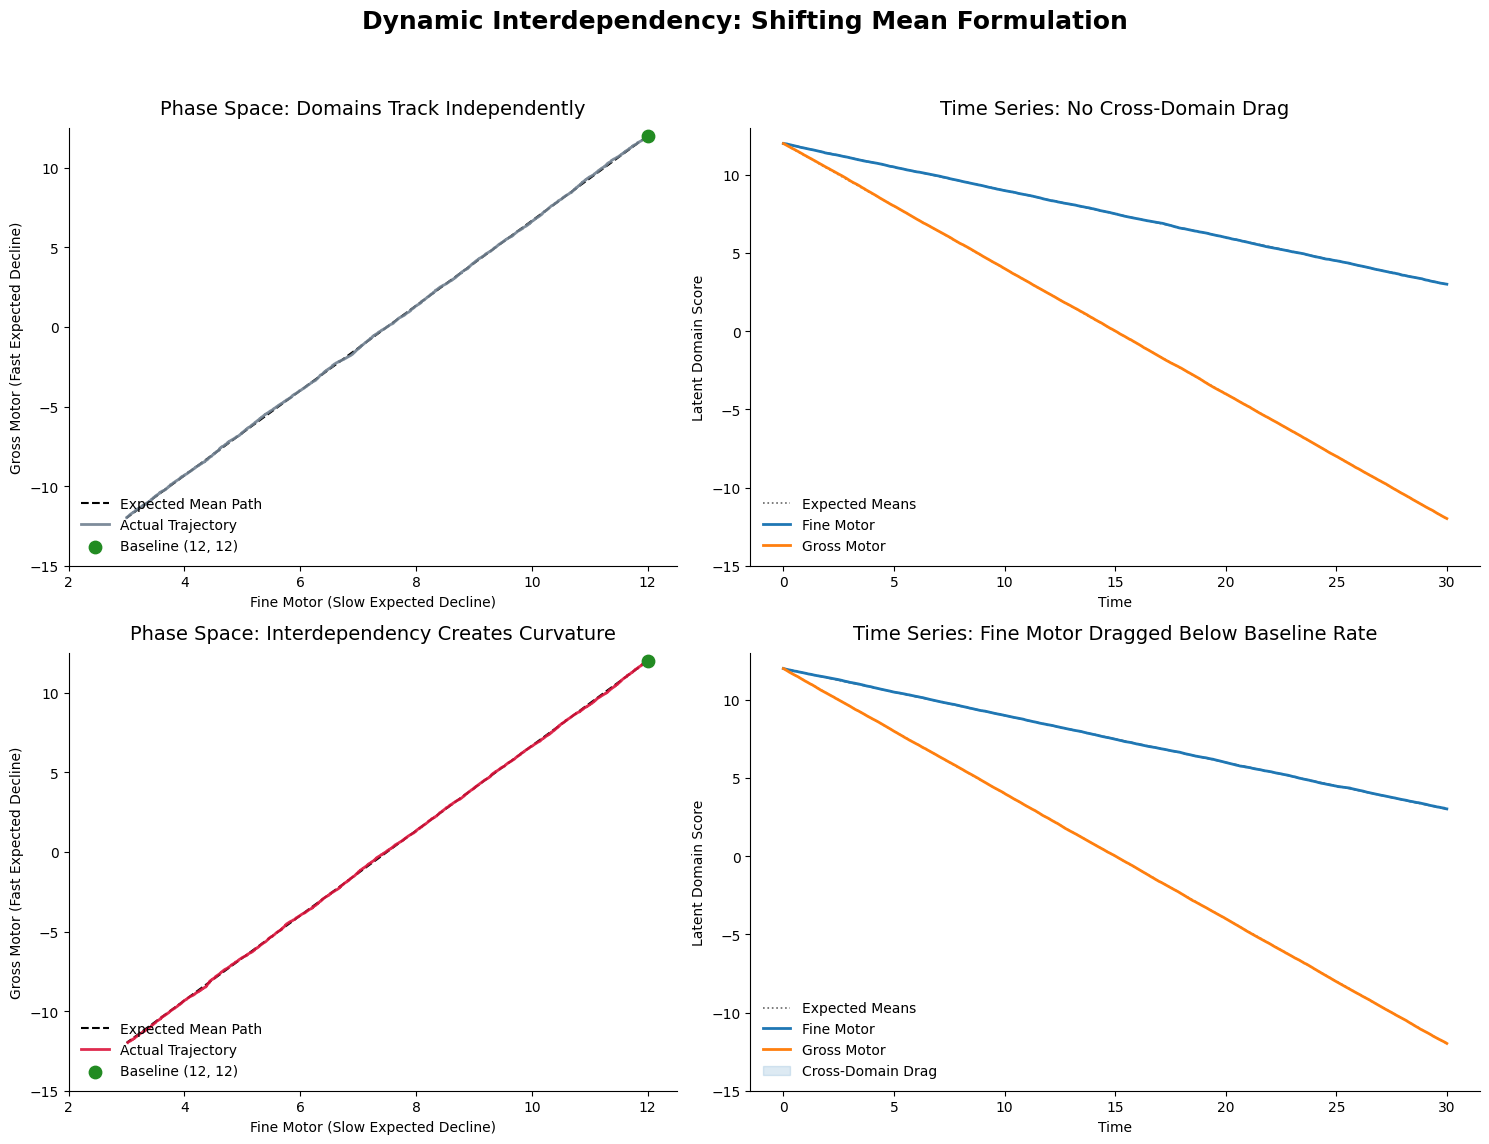

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_shifting_ou(Gamma, v, G, X0, dt, N):
    """
    Simulates a 2D OU process with a shifting linear mean: mu(t) = X0 + v * t
    """
    X = np.zeros((N, 2))
    X[0] = X0
    dW = np.random.normal(0, np.sqrt(dt), (N - 1, 2))
    time = np.arange(N) * dt
    
    for t in range(1, N):
        # The moving target (mean) at the current time
        mu_t = X0 + v * time[t-1]
        
        # The drift includes the baseline rate 'v' plus the reversion pull
        drift = (v - Gamma @ (X[t-1] - mu_t)) * dt
        diffusion = G @ dW[t-1]
        X[t] = X[t-1] + drift + diffusion
        
    return X, time

# --- System Parameters ---
N = 3000
dt = 0.01
X0 = np.array([12.0, 12.0]) # Start at maximum healthy score

# Baseline rates of decline: Fine Motor drops slowly (-0.3), Gross Motor drops fast (-0.8)
v = np.array([-0.3, -0.8])  

# Very low noise to isolate the deterministic interaction
G = np.array([[0.02, 0.0],  
              [0.0, 0.02]])

# --- 1. Independent (Real Eigenvalues) ---
# Diagonal only. No domain influences the other.
Gamma_real = np.array([[0.8, 0.0], 
                       [0.0, 0.8]])
X_real, time = simulate_shifting_ou(Gamma_real, v, G, X0, dt, N)

# --- 2. Interacting (Complex Eigenvalues) ---
# The rapid decline in Gross Motor exerts a "drag" on Fine Motor
Gamma_complex = np.array([[0.8, 0.6], 
                          [-0.6, 0.8]])
X_complex, _ = simulate_shifting_ou(Gamma_complex, v, G, X0, dt, N)

# Calculate theoretical mean paths
mean_path = X0 + np.outer(time, v)

# --- Plotting ---
fig, axes = plt.subplots(2, 2, figsize=(15, 12), gridspec_kw={'width_ratios': [1, 1.2]})
fig.suptitle('Dynamic Interdependency: Shifting Mean Formulation', fontsize=18, fontweight='bold', y=0.98)

def plot_phase_space(ax, X, title, is_complex=False):
    # Plot the expected non-interacting mean path
    ax.plot(mean_path[:, 0], mean_path[:, 1], color='black', linestyle='--', linewidth=1.5, label='Expected Mean Path')
    
    # Plot the actual latent trajectory
    color = 'crimson' if is_complex else 'slategray'
    ax.plot(X[:, 0], X[:, 1], color=color, alpha=0.9, linewidth=2.0, label='Actual Trajectory')
    
    ax.scatter(X0[0], X0[1], color='forestgreen', s=80, zorder=5, label='Baseline (12, 12)')
    
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel('Fine Motor (Slow Expected Decline)')
    ax.set_ylabel('Gross Motor (Fast Expected Decline)')
    
    # Lock axes to show the "bowing" effect perfectly
    ax.set_xlim(2, 12.5) 
    ax.set_ylim(-15, 12.5)
    
    ax.legend(loc='lower left', frameon=False)

def plot_time_series(ax, X, title, is_complex=False):
    # Plot expected means
    ax.plot(time, mean_path[:, 0], color='black', linestyle='--', linewidth=1.2, alpha=0.6)
    ax.plot(time, mean_path[:, 1], color='black', linestyle=':', linewidth=1.2, alpha=0.6, label='Expected Means')
    
    # Plot actual trajectories
    ax.plot(time, X[:, 0], label='Fine Motor', color='#1f77b4', linewidth=2.0)
    ax.plot(time, X[:, 1], label='Gross Motor', color='#ff7f0e', linewidth=2.0)
    
    if is_complex:
        # Highlight the area where Fine Motor is dragged down
        ax.fill_between(time, mean_path[:, 0], X[:, 0], color='#1f77b4', alpha=0.15, label='Cross-Domain Drag')

    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel('Time')
    ax.set_ylabel('Latent Domain Score')
    ax.set_ylim(-15, 13)
    ax.legend(loc='lower left', frameon=False)

# Top Row: Real
plot_phase_space(axes[0, 0], X_real, 'Phase Space: Domains Track Independently')
plot_time_series(axes[0, 1], X_real, 'Time Series: No Cross-Domain Drag')

# Bottom Row: Complex
plot_phase_space(axes[1, 0], X_complex, 'Phase Space: Interdependency Creates Curvature', is_complex=True)
plot_time_series(axes[1, 1], X_complex, 'Time Series: Fine Motor Dragged Below Baseline Rate', is_complex=True)

# Formatting cleanup
for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('shifting_mean_interdependency.png', dpi=300, bbox_inches='tight')
plt.show()

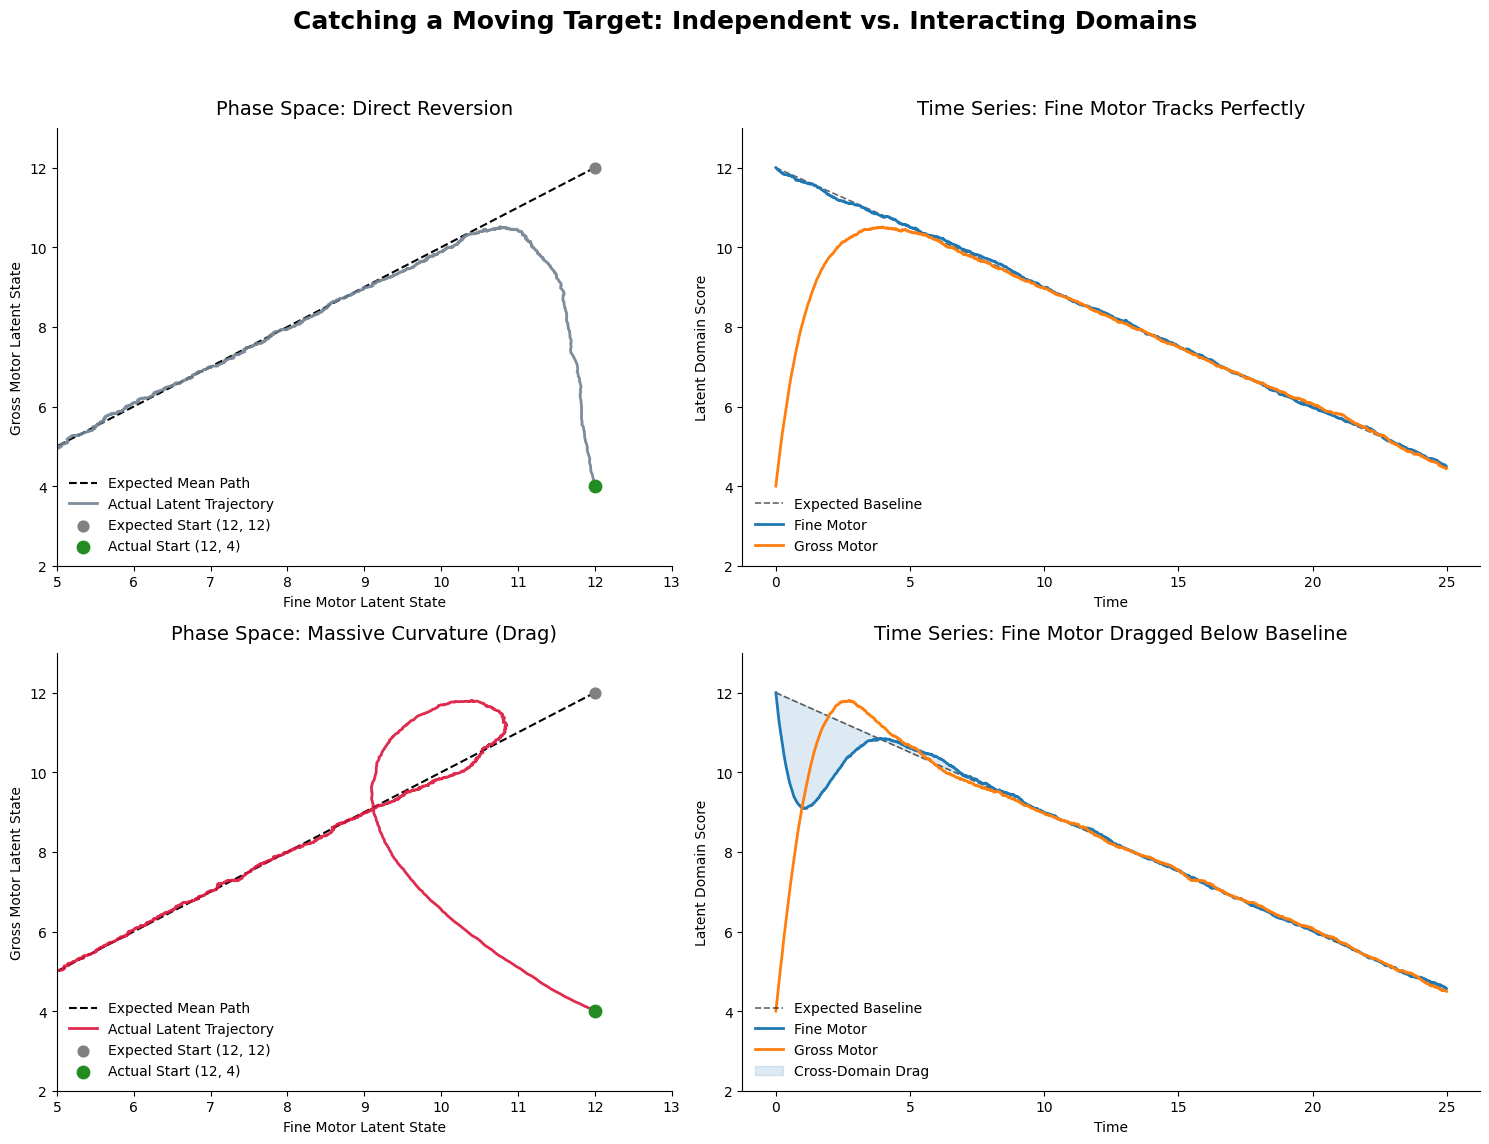

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_shifting_ou(Gamma, v, G, X0, mu0, dt, N):
    """
    Simulates a 2D OU process with a shifting linear mean: mu(t) = mu0 + v * t
    """
    X = np.zeros((N, 2))
    X[0] = X0
    dW = np.random.normal(0, np.sqrt(dt), (N - 1, 2))
    time = np.arange(N) * dt
    
    for t in range(1, N):
        # The moving target (mean) at the current time
        mu_t = mu0 + v * time[t-1]
        
        # The drift includes the baseline rate 'v' plus the reversion pull
        drift = (v - Gamma @ (X[t-1] - mu_t)) * dt
        diffusion = G @ dW[t-1]
        X[t] = X[t-1] + drift + diffusion
        
    return X, time

# --- System Parameters ---
N = 2500
dt = 0.01
mu0 = np.array([12.0, 12.0]) # Expected healthy baseline start
X0 = np.array([12.0, 4.0])   # Actual start: Fine Motor is fine (12), Gross Motor is degraded (4)

v = np.array([-0.3, -0.3])   # Expected slow decline over time for both domains
G = np.array([[0.05, 0.0],   # Low noise to isolate the deterministic drift
              [0.0, 0.05]])

# --- 1. Independent (Real Eigenvalues) ---
Gamma_real = np.array([[0.8, 0.0], 
                       [0.0, 0.8]])
X_real, time = simulate_shifting_ou(Gamma_real, v, G, X0, mu0, dt, N)

# --- 2. Interacting (Complex Eigenvalues) ---
# The negative off-diagonal ensures that a low Gross Motor score drags Fine Motor down.
Gamma_complex = np.array([[0.8, -0.8], 
                          [0.8, 0.8]])
X_complex, _ = simulate_shifting_ou(Gamma_complex, v, G, X0, mu0, dt, N)

# Calculate theoretical mean path for plotting
mean_path = mu0 + np.outer(time, v)

# --- Plotting ---
fig, axes = plt.subplots(2, 2, figsize=(15, 12), gridspec_kw={'width_ratios': [1, 1.2]})
fig.suptitle('Catching a Moving Target: Independent vs. Interacting Domains', fontsize=18, fontweight='bold', y=0.98)

def plot_phase_space(ax, X, title, is_complex=False):
    ax.plot(mean_path[:, 0], mean_path[:, 1], color='black', linestyle='--', linewidth=1.5, label='Expected Mean Path')
    color = 'crimson' if is_complex else 'slategray'
    ax.plot(X[:, 0], X[:, 1], color=color, alpha=0.9, linewidth=2.0, label='Actual Latent Trajectory')
    
    ax.scatter(mu0[0], mu0[1], color='gray', s=60, zorder=4, label='Expected Start (12, 12)')
    ax.scatter(X0[0], X0[1], color='forestgreen', s=80, zorder=5, label='Actual Start (12, 4)')
    
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel('Fine Motor Latent State')
    ax.set_ylabel('Gross Motor Latent State')
    
    # Locked axes to ensure the curvature is undeniable
    ax.set_xlim(5, 13) 
    ax.set_ylim(2, 13)
    ax.legend(loc='lower left', frameon=False)

def plot_time_series(ax, X, title, is_complex=False):
    ax.plot(time, mean_path[:, 0], color='black', linestyle='--', linewidth=1.2, alpha=0.6, label='Expected Baseline')
    
    ax.plot(time, X[:, 0], label='Fine Motor', color='#1f77b4', linewidth=2.0)
    ax.plot(time, X[:, 1], label='Gross Motor', color='#ff7f0e', linewidth=2.0)
    
    if is_complex:
        ax.fill_between(time, mean_path[:, 0], X[:, 0], color='#1f77b4', alpha=0.15, label='Cross-Domain Drag')

    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel('Time')
    ax.set_ylabel('Latent Domain Score')
    
    # Locked axes
    ax.set_ylim(2, 13)
    ax.legend(loc='lower left', frameon=False)

# Top Row: Real
plot_phase_space(axes[0, 0], X_real, 'Phase Space: Direct Reversion')
plot_time_series(axes[0, 1], X_real, 'Time Series: Fine Motor Tracks Perfectly')

# Bottom Row: Complex
plot_phase_space(axes[1, 0], X_complex, 'Phase Space: Massive Curvature (Drag)', is_complex=True)
plot_time_series(axes[1, 1], X_complex, 'Time Series: Fine Motor Dragged Below Baseline', is_complex=True)

for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('shifting_mean_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

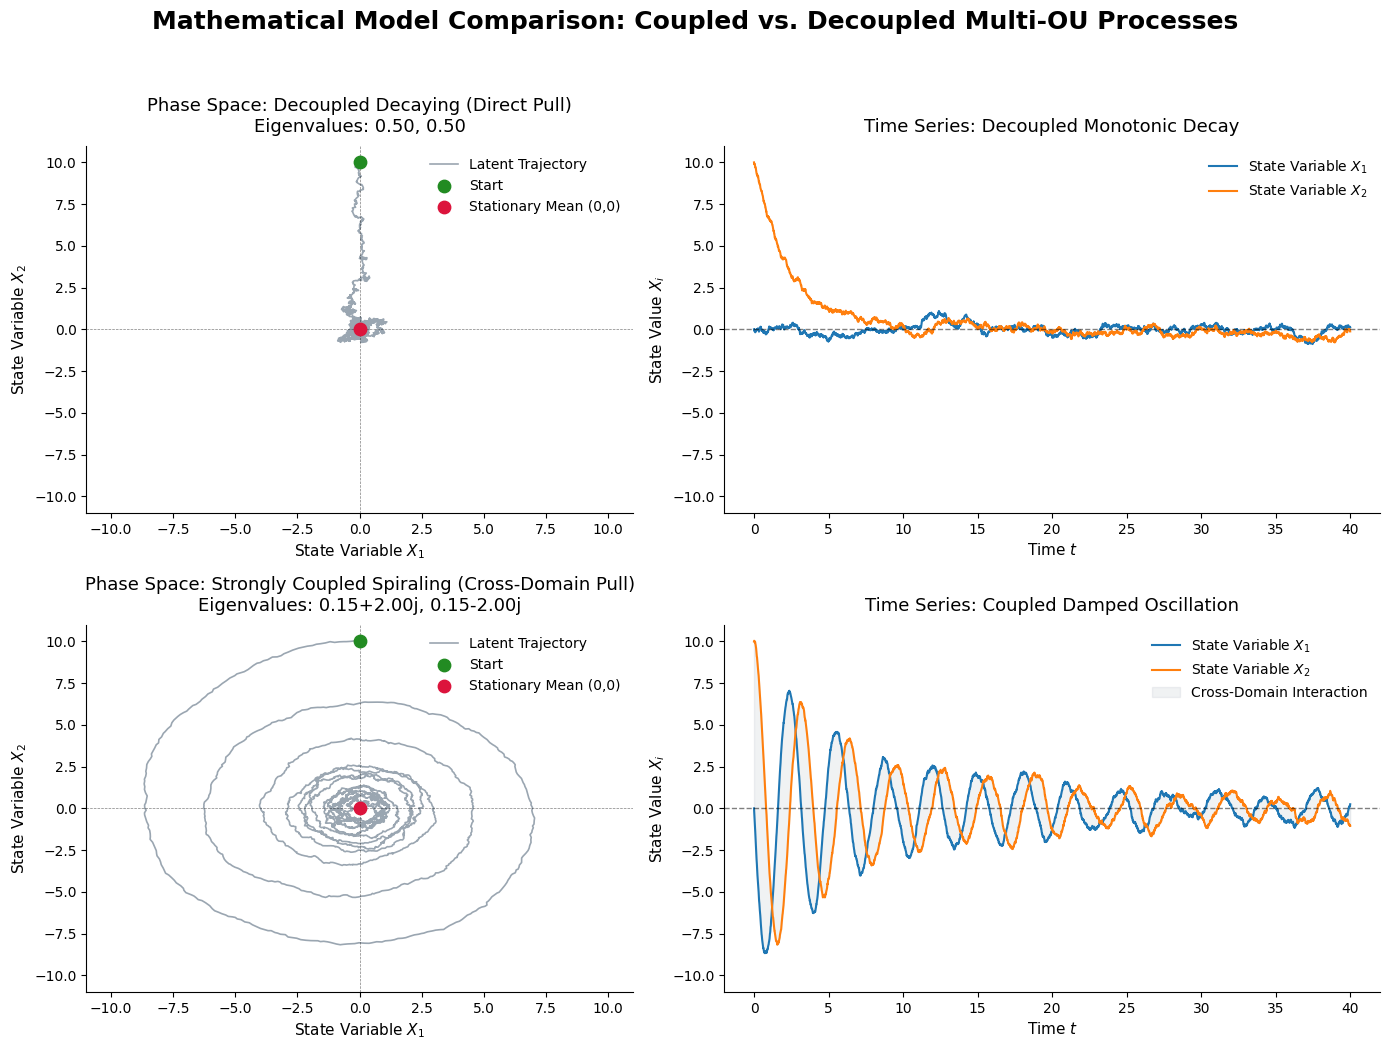

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_2d_ou(Gamma, mu, G, X0, dt, N):
    """
    Simulates a 2D OU process.
    dX_t = -Gamma @ (X_t - mu) dt + G @ dW_t
    """
    X = np.zeros((N, 2))
    X[0] = X0
    
    # Pre-generate noise for efficiency
    dW = np.random.normal(0, np.sqrt(dt), (N - 1, 2))
    
    # Euler-Maruyama integration
    for t in range(1, N):
        drift = -Gamma @ (X[t-1] - mu) * dt
        diffusion = G @ dW[t-1]
        X[t] = X[t-1] + drift + diffusion
        
    return X

# --- Shared Parameters ---
N = 4000                    # Number of time steps (longer for a full spiral)
dt = 0.01                   # Time step size
X0 = np.array([0.0, 10.0])  # Start off-origin to see the contractive path
mu = np.array([0.0, 0.0])   # Stationary mean at the origin for maximum visual clarity
G = np.array([[0.35, 0.0],  # Low volatility (noise) to isolate the drift structure
              [0.0, 0.35]])
time = np.arange(N) * dt

# --- 1. Decoupled System (Real Eigenvalues, Symmetric Gamma) ---
# Gamma has diagonal elements (decay) only. Domains do not interact.
# Eigenvalues are exactly 0.5 and 0.5.
Gamma_decoupled = np.array([[0.5, 0.0], 
                           [0.0, 0.5]])

X_decoupled = simulate_2d_ou(Gamma_decoupled, mu, G, X0, dt, N)
eig_decoupled = np.linalg.eigvals(Gamma_decoupled)
eig_decoupled_str = [f"{e.real:.2f}" for e in eig_decoupled]

# --- 2. Coupled System (Complex Eigenvalues, Skew Gamma) ---
# Dramatically increase the coupling (off-diagonal elements) while weakening decay (diagonal).
# The ratio of imaginary part (2.0) to real part (0.15) creates a powerful, clear spiral.
# Eigenvalues are 0.15 +/- 2.0j.
Gamma_coupled = np.array([[0.15, 2.0], 
                         [-2.0, 0.15]])

X_coupled = simulate_2d_ou(Gamma_coupled, mu, G, X0, dt, N)
eig_coupled = np.linalg.eigvals(Gamma_coupled)
eig_coupled_str = [f"{e.real:.2f}{e.imag:+.2f}j" for e in eig_coupled]

# --- Plotting for Presentation ---
fig, axes = plt.subplots(2, 2, figsize=(14, 11), gridspec_kw={'width_ratios': [1, 1.2]})
fig.suptitle('Mathematical Model Comparison: Coupled vs. Decoupled Multi-OU Processes', fontsize=18, fontweight='bold', y=0.98)

# Helper function to format phase space plots
def plot_phase_space(ax, X, title, eigenvalues):
    ax.plot(X[:, 0], X[:, 1], color='slategray', alpha=0.7, linewidth=1.2, label='Latent Trajectory')
    ax.scatter(X[0, 0], X[0, 1], color='forestgreen', s=80, zorder=5, label='Start')
    ax.scatter(mu[0], mu[1], color='crimson', s=80, zorder=5, label='Stationary Mean (0,0)')
    
    ax.set_title(f"{title}\nEigenvalues: {eigenvalues[0]}, {eigenvalues[1]}", fontsize=13, pad=10)
    ax.set_xlabel('State Variable $X_1$', fontsize=11)
    ax.set_ylabel('State Variable $X_2$', fontsize=11)
    
    # Lock axes so the distinction is undeniable
    ax.set_xlim(-11, 11) 
    ax.set_ylim(-11, 11)
    
    # Faint grid lines to center the spiral visually
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.axvline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', frameon=False)

# Helper function to format time series plots
def plot_time_series(ax, X, title, is_coupled=False):
    ax.plot(time, X[:, 0], label='State Variable $X_1$', color='#1f77b4', linewidth=1.5)
    ax.plot(time, X[:, 1], label='State Variable $X_2$', color='#ff7f0e', linewidth=1.5)
    
    if is_coupled:
        # Cross-coupling Interdependency Area (fill between the dimensions)
        ax.fill_between(time, X[:, 0], X[:, 1], color='slategray', alpha=0.1, label='Cross-Domain Interaction')

    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel('Time $t$', fontsize=11)
    ax.set_ylabel('State Value $X_i$', fontsize=11)
    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_ylim(-11, 11)
    ax.legend(loc='upper right', frameon=False)

# Top Row: Decoupled System
plot_phase_space(axes[0, 0], X_decoupled, 'Phase Space: Decoupled Decaying (Direct Pull)', eig_decoupled_str)
plot_time_series(axes[0, 1], X_decoupled, 'Time Series: Decoupled Monotonic Decay')

# Bottom Row: Coupled System
plot_phase_space(axes[1, 0], X_coupled, 'Phase Space: Strongly Coupled Spiraling (Cross-Domain Pull)', eig_coupled_str)
plot_time_series(axes[1, 1], X_coupled, 'Time Series: Coupled Damped Oscillation', is_coupled=True)

# Clean up visual formatting for a professional look
for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# Save the figure with high resolution for presentations
plt.savefig('ou_mathematical_comparison_strong.png', dpi=300, bbox_inches='tight')
plt.show()

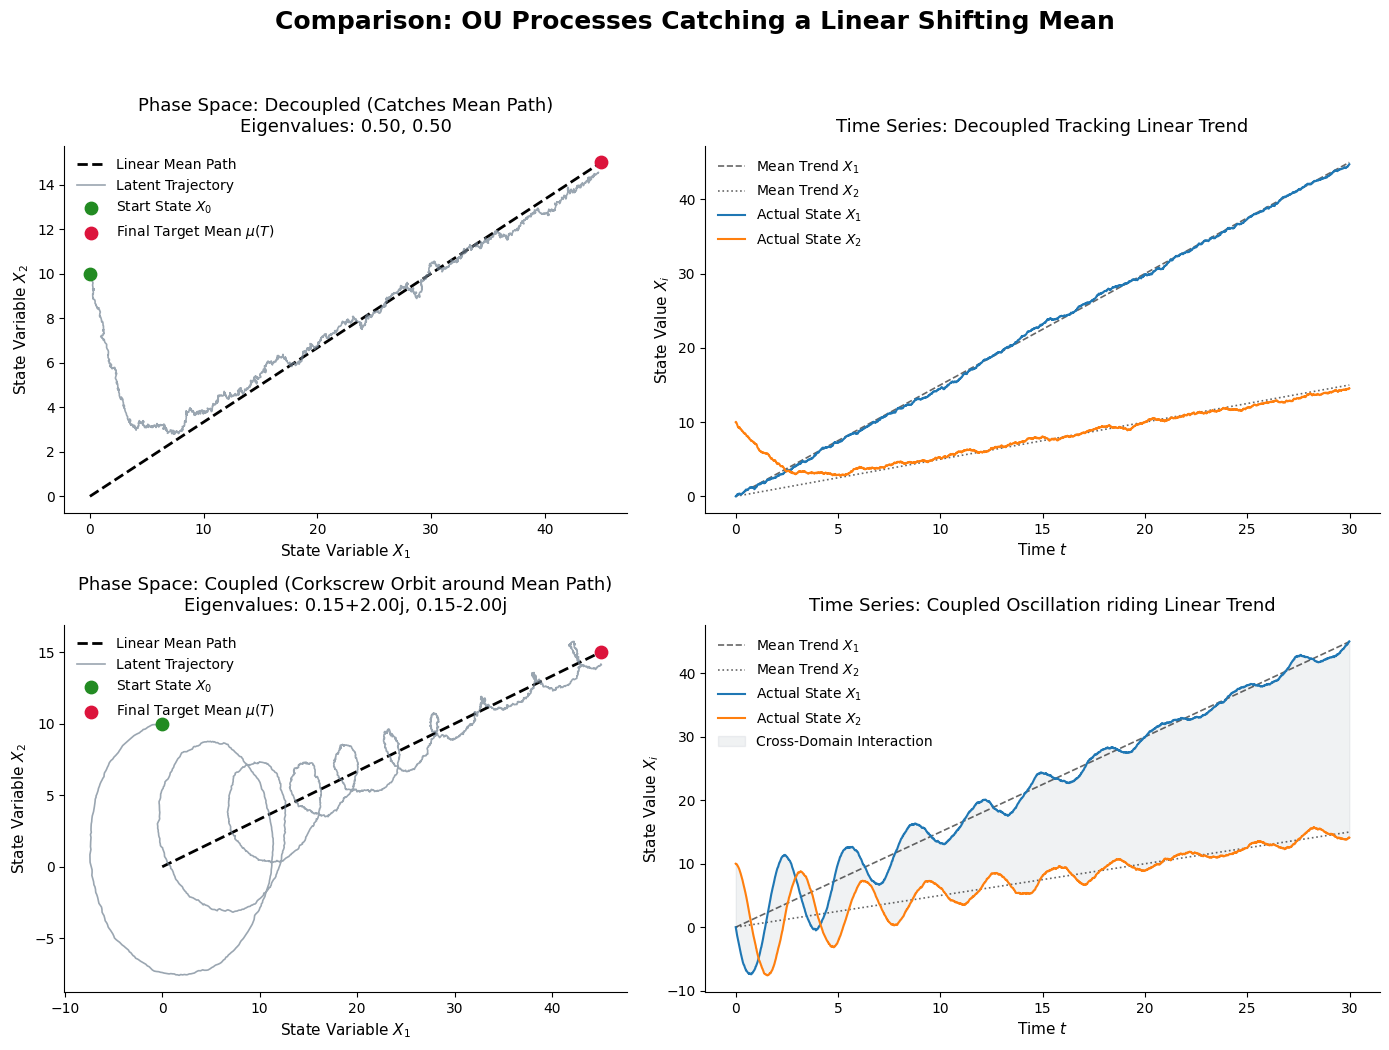

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_shifting_ou(Gamma, v, G, X0, mu0, dt, N):
    """
    Simulates a 2D OU process with a linear shifting mean mu(t) = mu0 + v * t
    """
    X = np.zeros((N, 2))
    X[0] = X0
    
    # Pre-generate noise for efficiency
    dW = np.random.normal(0, np.sqrt(dt), (N - 1, 2))
    time = np.arange(N) * dt
    
    # Euler-Maruyama integration
    for t in range(1, N):
        # The moving target (mean) at the current time
        mu_t = mu0 + v * time[t-1]
        
        # The drift includes the velocity 'v' (keeps it on target) and the Gamma pull
        drift = (v - Gamma @ (X[t-1] - mu_t)) * dt
        diffusion = G @ dW[t-1]
        X[t] = X[t-1] + drift + diffusion
        
    return X, time

# --- System Parameters ---
N = 3000                   # Number of time steps
dt = 0.01                  # Time step size
X0 = np.array([0.0, 10.0]) # Start far off the target mean path

# New Shifting Mean: Starts at origin, moves diagonally up-right
mu0 = np.array([0.0, 0.0])  # Mean start point
v = np.array([1.5, 0.5])   # Velocity vector for the mean trend

# Low volatility to isolate the drift pattern clearly
G = np.array([[0.35, 0.0],  
              [0.0, 0.35]])

# --- 1. Decoupled System (Real Eigenvalues, Symmetric Gamma) ---
# Gamma has diagonal elements (decay) only. Domains do not interact.
Gamma_decoupled = np.array([[0.5, 0.0], 
                           [0.0, 0.5]])

X_decoupled, time = simulate_shifting_ou(Gamma_decoupled, v, G, X0, mu0, dt, N)
eig_decoupled = np.linalg.eigvals(Gamma_decoupled)
eig_decoupled_str = [f"{e.real:.2f}" for e in eig_decoupled]

# --- 2. Coupled System (Complex Eigenvalues, Skew Gamma) ---
# Using the exact strong-coupling Gamma matrix from the original image (0.15 +/- 2.0j)
Gamma_coupled = np.array([[0.15, 2.0], 
                         [-2.0, 0.15]])

# FIX: Added mu0 to the arguments here
X_coupled, _ = simulate_shifting_ou(Gamma_coupled, v, G, X0, mu0, dt, N)
eig_coupled = np.linalg.eigvals(Gamma_coupled)
eig_coupled_str = [f"{e.real:.2f}{e.imag:+.2f}j" for e in eig_coupled]

# Calculate the theoretical mean trajectory path for plotting
mean_trajectory = mu0 + np.outer(time, v)

# --- Plotting ---
# Using a slightly wider figure to accommodate side-by-side plots nicely on a slide
fig, axes = plt.subplots(2, 2, figsize=(14, 11), gridspec_kw={'width_ratios': [1, 1.2]})
fig.suptitle('Comparison: OU Processes Catching a Linear Shifting Mean', fontsize=18, fontweight='bold', y=0.98)

# Helper function to format phase space plots
def plot_phase_space(ax, X, title, eigenvalues):
    # Plot the full theoretical mean trajectory path
    ax.plot(mean_trajectory[:, 0], mean_trajectory[:, 1], color='black', linestyle='--', linewidth=2.0, label='Linear Mean Path')
    
    # Plot the actual latent trajectory
    ax.plot(X[:, 0], X[:, 1], color='slategray', alpha=0.7, linewidth=1.2, label='Latent Trajectory')
    
    ax.scatter(X0[0], X0[1], color='forestgreen', s=80, zorder=5, label='Start State $X_0$')
    ax.scatter(mean_trajectory[-1, 0], mean_trajectory[-1, 1], color='crimson', s=80, zorder=5, label='Final Target Mean $\mu(T)$')
    
    ax.set_title(f"{title}\nEigenvalues: {eigenvalues[0]}, {eigenvalues[1]}", fontsize=13, pad=10)
    ax.set_xlabel('State Variable $X_1$', fontsize=11)
    ax.set_ylabel('State Variable $X_2$', fontsize=11)
    ax.legend(loc='upper left', frameon=False)

# Helper function to format time series plots
def plot_time_series(ax, X, title, is_coupled=False):
    # Plot the target means as simple lines
    ax.plot(time, mean_trajectory[:, 0], color='black', linestyle='--', linewidth=1.2, alpha=0.6, label='Mean Trend $X_1$')
    ax.plot(time, mean_trajectory[:, 1], color='black', linestyle=':', linewidth=1.2, alpha=0.6, label='Mean Trend $X_2$')
    
    # Plot actual trajectories
    ax.plot(time, X[:, 0], label='Actual State $X_1$', color='#1f77b4', linewidth=1.5)
    ax.plot(time, X[:, 1], label='Actual State $X_2$', color='#ff7f0e', linewidth=1.5)
    
    if is_coupled:
        # Cross-coupling Interdependency Area (fill between the dimensions)
        ax.fill_between(time, X[:, 0], X[:, 1], color='slategray', alpha=0.1, label='Cross-Domain Interaction')

    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel('Time $t$', fontsize=11)
    ax.set_ylabel('State Value $X_i$', fontsize=11)
    ax.legend(loc='upper left', frameon=False)

# Top Row: Decoupled System
plot_phase_space(axes[0, 0], X_decoupled, 'Phase Space: Decoupled (Catches Mean Path)', eig_decoupled_str)
plot_time_series(axes[0, 1], X_decoupled, 'Time Series: Decoupled Tracking Linear Trend')

# Bottom Row: Coupled System
plot_phase_space(axes[1, 0], X_coupled, 'Phase Space: Coupled (Corkscrew Orbit around Mean Path)', eig_coupled_str)
plot_time_series(axes[1, 1], X_coupled, 'Time Series: Coupled Oscillation riding Linear Trend', is_coupled=True)

# Clean up visual formatting for a professional slide look
for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# Save the figure with high resolution for presentations
plt.savefig('ou_shifting_mathematical_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

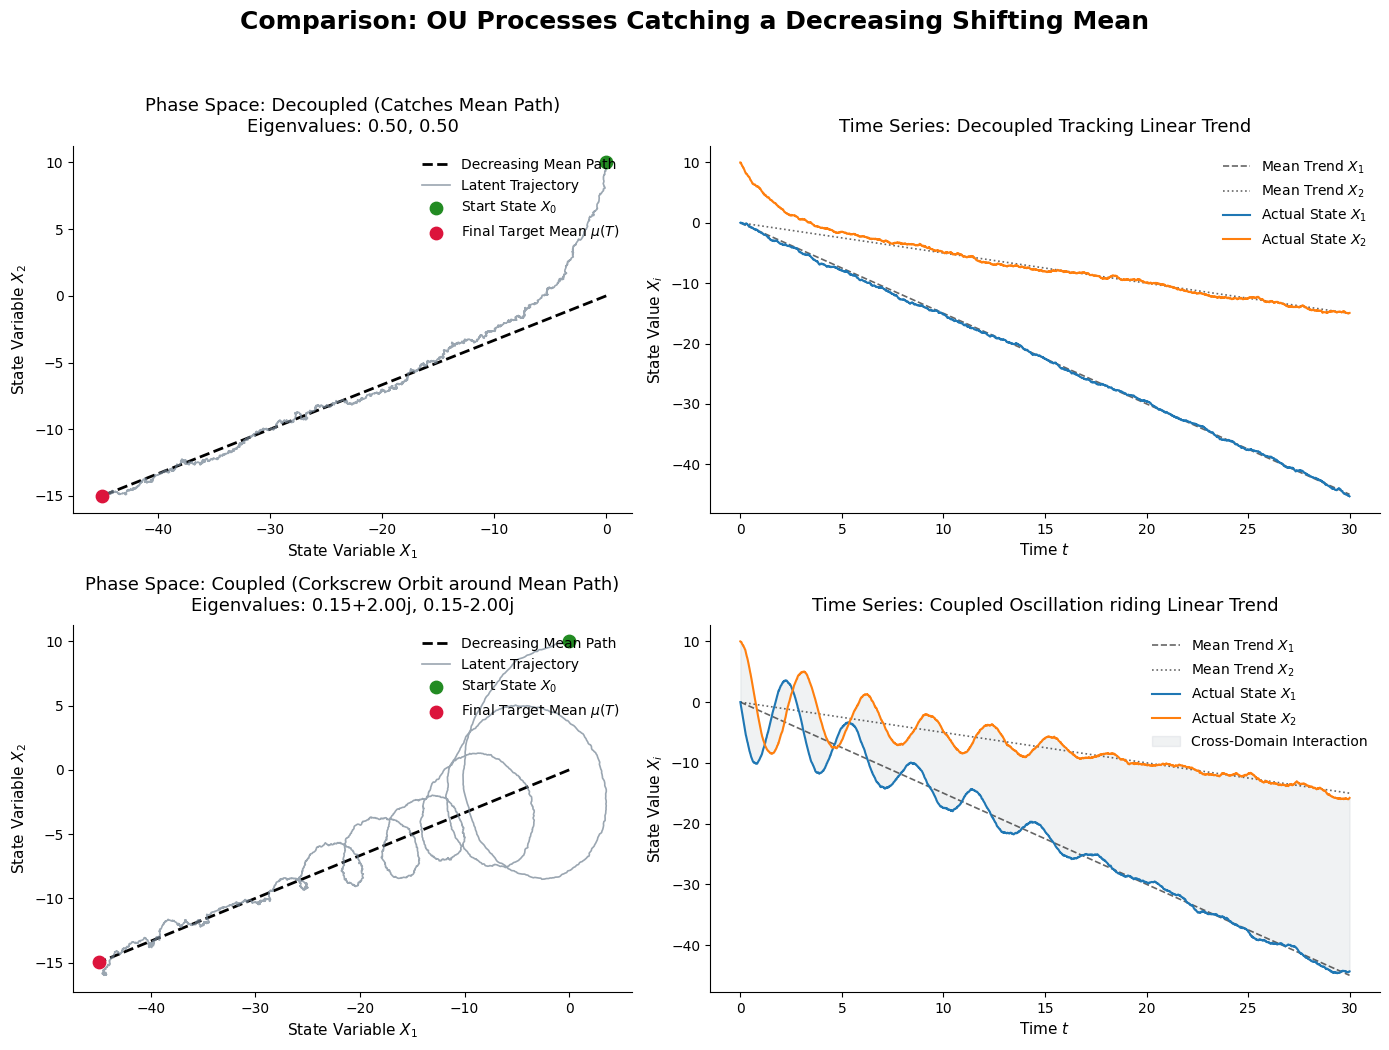

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_shifting_ou(Gamma, v, G, X0, mu0, dt, N):
    """
    Simulates a 2D OU process with a linear shifting mean mu(t) = mu0 + v * t
    """
    X = np.zeros((N, 2))
    X[0] = X0
    
    # Pre-generate noise for efficiency
    dW = np.random.normal(0, np.sqrt(dt), (N - 1, 2))
    time = np.arange(N) * dt
    
    # Euler-Maruyama integration
    for t in range(1, N):
        # The moving target (mean) at the current time
        mu_t = mu0 + v * time[t-1]
        
        # The drift includes the velocity 'v' (keeps it on target) and the Gamma pull
        drift = (v - Gamma @ (X[t-1] - mu_t)) * dt
        diffusion = G @ dW[t-1]
        X[t] = X[t-1] + drift + diffusion
        
    return X, time

# --- System Parameters ---
N = 3000                   # Number of time steps
dt = 0.01                  # Time step size
X0 = np.array([0.0, 10.0]) # Start far off the target mean path

# Shifting Mean: Starts at origin, moves diagonally DOWN-LEFT
mu0 = np.array([0.0, 0.0])  
v = np.array([-1.5, -0.5]) # CHANGED: Negative components for monotonic decrease

# Low volatility to isolate the drift pattern clearly
G = np.array([[0.35, 0.0],  
              [0.0, 0.35]])

# --- 1. Decoupled System (Real Eigenvalues, Symmetric Gamma) ---
Gamma_decoupled = np.array([[0.5, 0.0], 
                           [0.0, 0.5]])

X_decoupled, time = simulate_shifting_ou(Gamma_decoupled, v, G, X0, mu0, dt, N)
eig_decoupled = np.linalg.eigvals(Gamma_decoupled)
eig_decoupled_str = [f"{e.real:.2f}" for e in eig_decoupled]

# --- 2. Coupled System (Complex Eigenvalues, Skew Gamma) ---
Gamma_coupled = np.array([[0.15, 2.0], 
                         [-2.0, 0.15]])

X_coupled, _ = simulate_shifting_ou(Gamma_coupled, v, G, X0, mu0, dt, N)
eig_coupled = np.linalg.eigvals(Gamma_coupled)
eig_coupled_str = [f"{e.real:.2f}{e.imag:+.2f}j" for e in eig_coupled]

# Calculate the theoretical mean trajectory path for plotting
mean_trajectory = mu0 + np.outer(time, v)

# --- Plotting ---
fig, axes = plt.subplots(2, 2, figsize=(14, 11), gridspec_kw={'width_ratios': [1, 1.2]})
fig.suptitle('Comparison: OU Processes Catching a Decreasing Shifting Mean', fontsize=18, fontweight='bold', y=0.98)

# Helper function to format phase space plots
def plot_phase_space(ax, X, title, eigenvalues):
    ax.plot(mean_trajectory[:, 0], mean_trajectory[:, 1], color='black', linestyle='--', linewidth=2.0, label='Decreasing Mean Path')
    ax.plot(X[:, 0], X[:, 1], color='slategray', alpha=0.7, linewidth=1.2, label='Latent Trajectory')
    
    ax.scatter(X0[0], X0[1], color='forestgreen', s=80, zorder=5, label='Start State $X_0$')
    ax.scatter(mean_trajectory[-1, 0], mean_trajectory[-1, 1], color='crimson', s=80, zorder=5, label='Final Target Mean $\mu(T)$')
    
    ax.set_title(f"{title}\nEigenvalues: {eigenvalues[0]}, {eigenvalues[1]}", fontsize=13, pad=10)
    ax.set_xlabel('State Variable $X_1$', fontsize=11)
    ax.set_ylabel('State Variable $X_2$', fontsize=11)
    
    # Legend moved to upper right to avoid overlapping the downward path
    ax.legend(loc='upper right', frameon=False)

# Helper function to format time series plots
def plot_time_series(ax, X, title, is_coupled=False):
    ax.plot(time, mean_trajectory[:, 0], color='black', linestyle='--', linewidth=1.2, alpha=0.6, label='Mean Trend $X_1$')
    ax.plot(time, mean_trajectory[:, 1], color='black', linestyle=':', linewidth=1.2, alpha=0.6, label='Mean Trend $X_2$')
    
    ax.plot(time, X[:, 0], label='Actual State $X_1$', color='#1f77b4', linewidth=1.5)
    ax.plot(time, X[:, 1], label='Actual State $X_2$', color='#ff7f0e', linewidth=1.5)
    
    if is_coupled:
        ax.fill_between(time, X[:, 0], X[:, 1], color='slategray', alpha=0.1, label='Cross-Domain Interaction')

    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel('Time $t$', fontsize=11)
    ax.set_ylabel('State Value $X_i$', fontsize=11)
    
    # Legend moved to upper right to avoid overlapping the downward path
    ax.legend(loc='upper right', frameon=False)

# Top Row: Decoupled System
plot_phase_space(axes[0, 0], X_decoupled, 'Phase Space: Decoupled (Catches Mean Path)', eig_decoupled_str)
plot_time_series(axes[0, 1], X_decoupled, 'Time Series: Decoupled Tracking Linear Trend')

# Bottom Row: Coupled System
plot_phase_space(axes[1, 0], X_coupled, 'Phase Space: Coupled (Corkscrew Orbit around Mean Path)', eig_coupled_str)
plot_time_series(axes[1, 1], X_coupled, 'Time Series: Coupled Oscillation riding Linear Trend', is_coupled=True)

# Clean up visual formatting
for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('ou_decreasing_shifting_mean.png', dpi=300, bbox_inches='tight')
plt.show()